# Import Modules

In [2]:
# DataFrame Modules
import pandas as pd
import numpy as np

# Plotting Modules
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# Stats & ML Modules
import statsmodels.formula.api as smf
from itertools import combinations
from statannotations.Annotator import Annotator
from scipy.spatial.distance import jensenshannon
from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact, permutation_test
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.contingency_tables import StratifiedTable



# set pandas to display all columns and rows when viewing datasets
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Allow inline plotting
%matplotlib inline

# Prelim Work

In [5]:
# Load in filtered Biobank Dataset
clean_mane = pd.read_parquet('/slade/home/mr935/scripts/biobank_work/parquets/clean_mane.parquet', engine='pyarrow')

In [6]:
# Create separate Missense/Synonymous Consequence Column
clean_mane.rename(columns={'Consequence': 'VEP_Consequence'}, inplace=True)
clean_mane['Consequence'] = clean_mane['VEP_Consequence'].apply(lambda row: 'missense' if 'missense' in row else 'synonymous')

clean_mane.head()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Consequence
0,chr1-65568-A-C,ENSG00000186092,OR4F5,+,0.04,SpliceAI_DS_DL,5.0,5,ENST00000641515,missense_variant,64,4,2,K/Q,Aag/Cag,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.06),benign(0),2/3,ENST00000641515.2:c.4A>C,ENSP00000493376.2:p.Lys2Gln,NaN,None,None,18.990,1.964888,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.01,0.04,298.0,321.0,-135.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
1,chr1-65568-A-G,ENSG00000186092,OR4F5,+,0.02,SpliceAI_DS_DL,5.0,5,ENST00000641515,missense_variant,64,4,2,K/E,Aag/Gag,None,MODERATE,CCDS30547.2,None,None,NaN,deleterious_low_confidence(0.04),benign(0),2/3,ENST00000641515.2:c.4A>G,ENSP00000493376.2:p.Lys2Glu,NaN,None,None,19.220,1.994556,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.01,0.02,298.0,-48.0,-135.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
2,chr1-65571-A-C,ENSG00000186092,OR4F5,+,0.00,SpliceAI_DS_AG,295.0,2,ENST00000641515,"missense_variant,splice_region_variant",67,7,3,K/Q,Aag/Cag,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.47),benign(0.027),2/3,ENST00000641515.2:c.7A>C,ENSP00000493376.2:p.Lys3Gln,NaN,None,None,16.030,1.545987,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.00,0.00,295.0,-51.0,2.0,-138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
3,chr1-69037-G-T,ENSG00000186092,OR4F5,+,0.19,SpliceAI_DS_AG,10.0,0,ENST00000641515,"missense_variant,splice_region_variant",70,10,4,V/L,Gta/Tta,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.12),benign(0.018),3/3,ENST00000641515.2:c.10G>T,ENSP00000493376.2:p.Val4Leu,NaN,None,None,12.030,1.032664,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.19,0.17,0.01,0.00,10.0,0.0,56.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
4,chr1-69038-T-C,ENSG00000186092,OR4F5,+,0.03,SpliceAI_DS_AL,-1.0,1,ENST00000641515,"missense_variant,splice_region_variant",71,11,4,V/A,gTa/gCa,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.3),benign(0),3/3,ENST00000641515.2:c.11T>C,ENSP00000493376.2:p.Val4Ala,NaN,None,None,7.806,0.630509,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.02,0.03,0.00,0.00,9.0,-1.0,55.0,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense


## MAF Work

In [7]:
# Define AF bins + labels
af_bins = [-np.inf, 0, 1e-4, 1e-3, 0.01, 1]
af_labels = [
    'gnomAD Unobserved',
    '0 < AF <= 0.01% (Ultra-Rare)',
    '0.01% < AF <= 0.1% (Rare)',
    '0.1% < AF <= 1% (Low-Frequency)',
    'AF > 1% (Common)'
]

In [8]:
# Assign AF bins to clean_mane
clean_mane['gnomADg_AF'] = pd.to_numeric(
    clean_mane['gnomADg_AF'], errors='coerce'
).fillna(0)

clean_mane['AF_Tier'] = pd.cut(
    clean_mane['gnomADg_AF'],
    bins=af_bins,
    labels=af_labels,
    right=True
)

In [9]:
# Define SpliceAI's Thresholds
for t in [0.2, 0.5, 0.8]:
    clean_mane[f'SpliceAI_{t}'] = (clean_mane['Max_SpliceAI_Score'] >= t).astype(int)

In [18]:
# Aggregate Proportions by Consequence, AF, and Thresholds
summary_stats = (
    clean_mane.groupby(["Consequence", "AF_Tier"], observed=False)
.agg(
        Total_Variants=("gnomADg_AF", "count"),
        SpliceAI_02=("SpliceAI_0.2", lambda x: f'{np.mean(x) * 100:.2f}%'),
        SpliceAI_05=("SpliceAI_0.5", lambda x: f'{np.mean(x) * 100:.2f}%'),
        SpliceAI_08=("SpliceAI_0.8", lambda x: f'{np.mean(x) * 100:.2f}%')
    ).reset_index()
)

summary_stats

,Consequence,AF_Tier,Total_Variants,SpliceAI_02,SpliceAI_05,SpliceAI_08
0,missense,gnomAD Unobserved,5947473,2.80%,0.88%,0.33%
1,missense,0 < AF <= 0.01% (Ultra-Rare),2044509,2.53%,0.70%,0.24%
2,missense,0.01% < AF <= 0.1% (Rare),221902,2.20%,0.53%,0.18%
3,missense,0.1% < AF <= 1% (Low-Frequency),68213,2.06%,0.46%,0.11%
4,missense,AF > 1% (Common),41161,1.67%,0.33%,0.10%
5,synonymous,gnomAD Unobserved,2440381,2.84%,0.85%,0.31%
6,synonymous,0 < AF <= 0.01% (Ultra-Rare),1068620,2.70%,0.73%,0.26%
7,synonymous,0.01% < AF <= 0.1% (Rare),146390,2.27%,0.54%,0.19%
8,synonymous,0.1% < AF <= 1% (Low-Frequency),54806,2.00%,0.44%,0.15%
9,synonymous,AF > 1% (Common),43260,1.58%,0.30%,0.08%


In [19]:
def calculate_tier_similarity(missense_row, synonymous_row, score_column):
    # Total variant counts per consequence group
    total_missense_variants = missense_row["Total_Variants"]
    total_synonymous_variants = synonymous_row["Total_Variants"]

    # Proportions per consequence
    missense_proportion = missense_row[score_column] / 100
    synonymous_proportion = synonymous_row[score_column] / 100

    # Reconstruct raw variant counts meeting the SpliceAI threshold from percentages
    missense_count = int(total_missense_variants * (missense_row[score_column] / 100))
    synonymous_count = int(total_synonymous_variants * (synonymous_row[score_column] / 100))

    # Obtain counts not meeting the threshold (negative)
    missense_neg_count = total_missense_variants - missense_count
    synonymous_neg_count = total_synonymous_variants - synonymous_count


    # Cohen's h (Effect size measure for proportion differences)
    cohens_h = 2 * (
        np.arcsin(np.sqrt(missense_proportion))
        - np.arcsin(np.sqrt(synonymous_proportion))
    )

    # Odds Ratio and 95% Confidence Intervals
    contingency_table = [
        [missense_count, missense_neg_count],
        [synonymous_count, synonymous_neg_count]
    ]

    odds_ratio, p_value = fisher_exact(contingency_table)

    standard_error = np.sqrt(
        (1 / missense_count)
        + (1 / missense_neg_count)
        + (1 / synonymous_count)
        + (1 / synonymous_neg_count)
    )

    log_odds_ratio = np.log(odds_ratio)
    ci_lower = np.exp(log_odds_ratio - (1.96 * standard_error))
    ci_upper = np.exp(log_odds_ratio + (1.96 * standard_error))

    return {
        "AF_Tier": missense_row["AF_Tier"],
        "Threshold": score_column,
        "Missense_Pct": missense_row[score_column],
        "Synonymous_Pct": synonymous_row[score_column],
        "Difference_Pct": (missense_proportion - synonymous_proportion) * 100,
        "Cohens_h": cohens_h,
        "Odds_Ratio": odds_ratio,
        "P_Value": p_value,
        "OR_CI_Lower": ci_lower,
        "OR_CI_Upper": ci_upper,
    }

In [20]:
def compare_all_thresholds_and_tiers(summary_df, threshold_columns):
    """Iterates through all AF_Tiers and SpliceAI threshold columns in the summary table,
    returning a similarity analysis DataFrame.
    """
    comparison_records = []
    unique_af_tiers = summary_df["AF_Tier"].unique()

    for tier in unique_af_tiers:
        # Extract rows corresponding to current AF tier
        missense_data = summary_df[
            (summary_df["Consequence"] == "missense")
            & (summary_df["AF_Tier"] == tier)
        ].iloc[0]

        synonymous_data = summary_df[
            (summary_df["Consequence"] == "synonymous")
            & (summary_df["AF_Tier"] == tier)
        ].iloc[0]
    
        # Loop through every SpliceAI column
        for score_column in threshold_columns:
            tier_metrics = calculate_tier_similarity(
                missense_row=missense_data,
                synonymous_row=synonymous_data,
                score_column=score_column,
            )
            comparison_records.append(tier_metrics)

    return pd.DataFrame(comparison_records)



# Run functions
threshold_cols = ["SpliceAI_02", "SpliceAI_05", "SpliceAI_08"]

for col in threshold_cols:
    summary_stats[col] = (
        summary_stats[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
    )
    summary_stats[col] = pd.to_numeric(summary_stats[col], errors='coerce')

summary_stats["Total_Variants"] = pd.to_numeric(summary_stats["Total_Variants"], errors='coerce')

similarity_results_df = compare_all_thresholds_and_tiers(
    summary_stats,
    threshold_cols
)

similarity_results_df

,AF_Tier,Threshold,Missense_Pct,Synonymous_Pct,Difference_Pct,Cohens_h,Odds_Ratio,P_Value,OR_CI_Lower,OR_CI_Upper
0,gnomAD Unobserved,SpliceAI_02,2.80,2.84,-0.04,-0.002416,0.985520,1.484077e-03,0.976702,0.994418
1,gnomAD Unobserved,SpliceAI_05,0.88,0.85,0.03,0.003240,1.035604,2.102593e-05,1.019013,1.052466
2,gnomAD Unobserved,SpliceAI_08,0.33,0.31,0.02,0.003542,1.064719,3.467825e-06,1.036806,1.093384
3,0 < AF <= 0.01% (Ultra-Rare),SpliceAI_02,2.53,2.70,-0.17,-0.010654,0.935426,4.058212e-19,0.921872,0.949179
4,0 < AF <= 0.01% (Ultra-Rare),SpliceAI_05,0.70,0.73,-0.03,-0.003561,0.958691,2.900906e-03,0.932514,0.985603
5,0 < AF <= 0.01% (Ultra-Rare),SpliceAI_08,0.24,0.26,-0.02,-0.004006,0.922874,7.899069e-04,0.880856,0.966896
6,0.01% < AF <= 0.1% (Rare),SpliceAI_02,2.20,2.27,-0.07,-0.004736,0.968314,1.572068e-01,0.926092,1.012461
7,0.01% < AF <= 0.1% (Rare),SpliceAI_05,0.53,0.54,-0.01,-0.001371,0.981947,6.945321e-01,0.897068,1.074858
8,0.01% < AF <= 0.1% (Rare),SpliceAI_08,0.18,0.19,-0.01,-0.002327,0.946748,5.040512e-01,0.812217,1.103562
9,0.1% < AF <= 1% (Low-Frequency),SpliceAI_02,2.06,2.00,0.06,0.004255,1.030605,4.644306e-01,0.951557,1.116221


In [21]:
def compute_mantel_haenszel(
    summary_df: pd.DataFrame,
    threshold_columns: list = ["SpliceAI_02", "SpliceAI_05", "SpliceAI_08"],
) -> pd.DataFrame:
    """Calculates Mantel-Haenszel Pooled Odds Ratio by stratifying STRICTLY
    across AF Tiers for each threshold independently (preventing double counting).
    """
    results = []
    unique_af_tiers = summary_df["AF_Tier"].unique()

    for score_col in threshold_columns:
        strata_tables = []

        for tier in unique_af_tiers:
            missense_rows = summary_df[
                (summary_df["Consequence"] == "missense")
                & (summary_df["AF_Tier"] == tier)
            ]
            synonymous_rows = summary_df[
                (summary_df["Consequence"] == "synonymous")
                & (summary_df["AF_Tier"] == tier)
            ]

            if missense_rows.empty or synonymous_rows.empty:
                continue

            missense_row = missense_rows.iloc[0]
            synonymous_row = synonymous_rows.iloc[0]

            total_missense = missense_row["Total_Variants"]
            total_synonymous = synonymous_row["Total_Variants"]

            missense_pos = int(
                round(total_missense * (missense_row[score_col] / 100))
            )
            synonymous_pos = int(
                round(total_synonymous * (synonymous_row[score_col] / 100))
            )

            missense_neg = total_missense - missense_pos
            synonymous_neg = total_synonymous - synonymous_pos

            # 2x2 matrix for this specific AF Tier
            matrix = [
                [missense_pos, missense_neg],
                [synonymous_pos, synonymous_neg],
            ]
            strata_tables.append(matrix)

        if not strata_tables:
            continue

        # Convert from shape (n_strata, 2, 2) to required shape (2, 2, n_strata)
        stratified_array = np.array(strata_tables).transpose(1, 2, 0)
        mh_analysis = StratifiedTable(stratified_array)

        ci_lower, ci_upper = mh_analysis.oddsratio_pooled_confint()

        results.append(
            {
                "Threshold": score_col,
                "Pooled_Odds_Ratio": mh_analysis.oddsratio_pooled,
                "OR_95_CI_Lower": ci_lower,
                "OR_95_CI_Upper": ci_upper,
                "Mantel_Haenszel_P_Value": mh_analysis.test_null_odds().pvalue,
            }
        )

    return pd.DataFrame(results)


# Execute corrected pooling:
correct_mh_df = compute_mantel_haenszel(summary_stats)
correct_mh_df

,Threshold,Pooled_Odds_Ratio,OR_95_CI_Lower,OR_95_CI_Upper,Mantel_Haenszel_P_Value
0,SpliceAI_02,0.972359,0.965104,0.979668,2.218226e-13
1,SpliceAI_05,1.015358,1.001531,1.029376,2.941531e-02
2,SpliceAI_08,1.025589,1.002568,1.049139,2.928020e-02


## Gather Paper Stats

In [22]:
# Split dataframe by consequence
missense = clean_mane[clean_mane['Consequence'] == 'missense']
synonymous = clean_mane[clean_mane['Consequence'] == 'synonymous']

In [23]:
len(missense)

8323258

In [24]:
high_splice = missense[missense['Max_SpliceAI_Score'] >= 0.2]
high_splice.head()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Consequence,AF_Tier,SpliceAI_0.2,SpliceAI_0.5,SpliceAI_0.8
6,chr1-69040-A-G,ENSG00000186092,OR4F5,+,0.31,SpliceAI_DS_AG,1.0,3,ENST00000641515,missense_variant,73,13,5,T/A,Act/Gct,None,MODERATE,CCDS30547.2,None,None,NaN,deleterious_low_confidence(0.02),benign(0),3/3,ENST00000641515.2:c.13A>G,ENSP00000493376.2:p.Thr5Ala,NaN,None,None,6.861,0.534491,NaN,None,NaN,None,NaN,NaN,0.0000,3.488700e-01,1.828,False,0.31,0.03,0.00,0.0,1.0,-3.0,53.0,-4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense,gnomAD Unobserved,1,0,0
1402,chr1-450844-T-A,ENSG00000284733,OR4F29,-,0.24,SpliceAI_DS_AG,-19.0,381807,ENST00000426406,missense_variant,835,835,279,T/S,Act/Tct,None,MODERATE,CCDS72675.1,Q6IEY1.151,None,NaN,deleterious_low_confidence(0.01),possibly_damaging(0.696),1/1,ENST00000426406.4:c.835A>T,ENSP00000409316.1:p.Thr279Ser,NaN,None,None,22.900,2.712599,NaN,None,NaN,None,NaN,0.299990,NaN,NaN,NaN,True,0.24,0.00,0.01,0.0,-19.0,-35.0,-65.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense,gnomAD Unobserved,1,0,0
1489,chr1-686592-C-A,ENSG00000284662,OR4F16,-,0.21,SpliceAI_DS_DG,2.0,238356,ENST00000332831,missense_variant,63,63,21,W/C,tgG/tgT,None,MODERATE,CCDS41221.1,Q6IEY1.151,None,NaN,deleterious_low_confidence(0),possibly_damaging(0.9),1/1,ENST00000332831.5:c.63G>T,ENSP00000329982.2:p.Trp21Cys,NaN,None,None,22.800,2.666145,0.038,None,NaN,None,NaN,0.536091,NaN,NaN,NaN,True,0.01,0.00,0.21,0.0,-152.0,-399.0,2.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense,gnomAD Unobserved,1,0,0
1528,chr1-686608-C-A,ENSG00000284662,OR4F16,-,0.22,SpliceAI_DS_DG,2.0,238340,ENST00000332831,missense_variant,47,47,16,G/V,gGa/gTa,None,MODERATE,CCDS41221.1,Q6IEY1.151,None,NaN,deleterious_low_confidence(0),probably_damaging(0.981),1/1,ENST00000332831.5:c.47G>T,ENSP00000329982.2:p.Gly16Val,NaN,None,None,22.400,2.482672,0.144,None,NaN,None,NaN,0.676890,NaN,NaN,NaN,True,0.02,0.00,0.22,0.0,-148.0,-453.0,2.0,-61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense,gnomAD Unobserved,1,0,0
1960,chr1-924948-G-A,ENSG00000187634,SAMD11,+,0.80,SpliceAI_DS_DL,0.0,0,ENST00000616016,"missense_variant,splice_region_variant",1026,517,173,G/R,Ggg/Agg,rs968674502,MODERATE,CCDS90834.1,None,None,1.0,deleterious_low_confidence(0),probably_damaging(0.991),1/14,ENST00000616016.5:c.517G>A,ENSP00000478421.2:p.Gly173Arg,0.000048,gnomADg_AFR,None,22.100,2.408234,NaN,None,NaN,None,NaN,NaN,1.4559,4.095700e-33,1.764,False,0.00,0.00,0.12,0.8,-256.0,-198.0,241.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000013,0.000048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,missense,0 < AF <= 0.01% (Ultra-Rare),1,1,1


In [25]:
len(high_splice)

225430

225,430 MANE Select variants in UK Biobank have a SpliceAI delta equal to or greater than 0.2

In [1]:
225430 / 8323258 * 100

2.7084346057757673

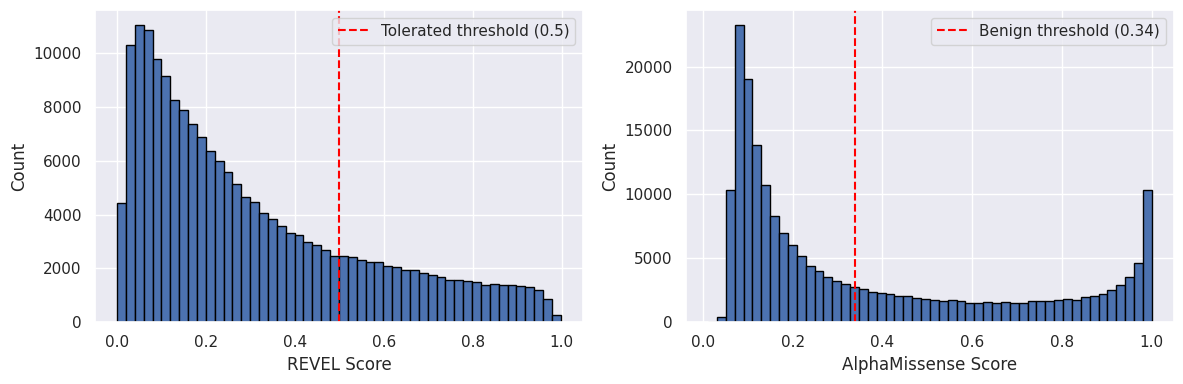

In [26]:
sns.set_theme()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# REVEL distribution
axes[0].hist(high_splice['REVEL'], bins=50, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', label='Tolerated threshold (0.5)')
axes[0].set_xlabel('REVEL Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# AlphaMissense distribution
axes[1].hist(high_splice['am_pathogenicity'], bins=50, edgecolor='black')
axes[1].axvline(0.34, color='red', linestyle='--', label='Benign threshold (0.34)')
axes[1].set_xlabel('AlphaMissense Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()

In [27]:
len(synonymous[synonymous['Max_SpliceAI_Score'] >= 0.2])

103153

In [28]:
len(synonymous)

3753457

In [29]:
103153 / 3753457 * 100

2.7482131805426304

In [30]:
len(missense[missense['Max_SpliceAI_Score'] >= 0.5])

68177

In [31]:
68177 / 8323258 * 100

0.8191143420040566

In [32]:
len(synonymous[synonymous['Max_SpliceAI_Score'] >= 0.5])

29639

In [33]:
29639 / 3753457 * 100

0.7896453855738856

In [34]:
len(missense[missense['Max_SpliceAI_Score'] >= 0.8]) / 8323258 * 100

0.30558946989267904

In [35]:
len(synonymous[synonymous['Max_SpliceAI_Score'] >= 0.8])

10812

In [36]:
10812 / 3753457 * 100

0.2880544522023297

### Gather Stats for Missense Scores

In [37]:
high_splice_missense = high_splice[(high_splice['REVEL'].notna()) & (high_splice['am_pathogenicity'].notna())]

In [38]:
len(high_splice_missense)

174896

In [39]:
len(high_splice_missense[(high_splice_missense['am_pathogenicity'] < 0.34) & (high_splice_missense['REVEL'] < 0.5)])

99913

In [40]:
99913 / 174896 * 100

57.12709267221663

57.1% of variants with a SpliceAI >= 0.2 and missense scores have both low AlphaMissense & REVEL scores.

In [41]:
len(high_splice[high_splice['am_pathogenicity'] < 0.34])

124074

In [42]:
len(high_splice[high_splice['am_pathogenicity'].isna()])

25256

In [43]:
len(high_splice_missense[high_splice_missense['am_pathogenicity'] < 0.34])

107695

In [44]:
len(high_splice_missense[high_splice_missense['REVEL'] < 0.5])

136086

In [45]:
len(high_splice_missense[(high_splice_missense['am_pathogenicity'] < 0.34) | (high_splice_missense['REVEL'] < 0.5)])

143868

In [46]:
143868 / 174896 * 100

82.25917116457781

# Figure 1

## A) Distribution Figure

In [47]:
# Generate variant counts at each SpliceAI score for each consequence
missense_splice_counts = missense.groupby('Max_SpliceAI_Score').size().reset_index(name='counts')
synonymous_splice_counts = synonymous.groupby('Max_SpliceAI_Score').size().reset_index(name='counts')

# Identify proportion of variants per consequence at each SpliceAI score
missense_splice_counts['proportion'] = missense_splice_counts['counts'] / len(missense)
synonymous_splice_counts['proportion'] = synonymous_splice_counts['counts'] / len(synonymous)

# Label appropriately
missense_splice_counts['consequence'] = 'Missense'
synonymous_splice_counts['consequence'] = 'Synonymous'

# Create final single dataset for both consequences
splice_counts = pd.concat([missense_splice_counts, synonymous_splice_counts])
splice_counts.head()

,Max_SpliceAI_Score,counts,proportion,consequence
0,0.00,4508140,0.541632,Missense
1,0.01,1567073,0.188276,Missense
2,0.02,611023,0.073412,Missense
3,0.03,348720,0.041897,Missense
4,0.04,231571,0.027822,Missense


In [48]:
# Create Survival Plot Table
splice_counts_survival = splice_counts.sort_values(['consequence', 'Max_SpliceAI_Score'], ascending=[True, False])
splice_counts_survival['cumulative_prop'] = splice_counts_survival.groupby('consequence')['proportion'].cumsum()
splice_counts_survival['cumulative_perc'] = splice_counts_survival.groupby('consequence')['proportion'].cumsum() * 100
# Force Missense to be the last category so its on top
splice_counts_survival['consequence'] = pd.Categorical(
    splice_counts_survival['consequence'], 
    categories=['Synonymous', 'Missense'], 
    ordered=True
)

splice_counts_survival.head()

,Max_SpliceAI_Score,counts,proportion,consequence,cumulative_prop,cumulative_perc
100,1.00,923,0.000111,Missense,0.000111,0.011089
99,0.99,1630,0.000196,Missense,0.000307,0.030673
98,0.98,1476,0.000177,Missense,0.000484,0.048407
97,0.97,1383,0.000166,Missense,0.000650,0.065023
96,0.96,1419,0.000170,Missense,0.000821,0.082071


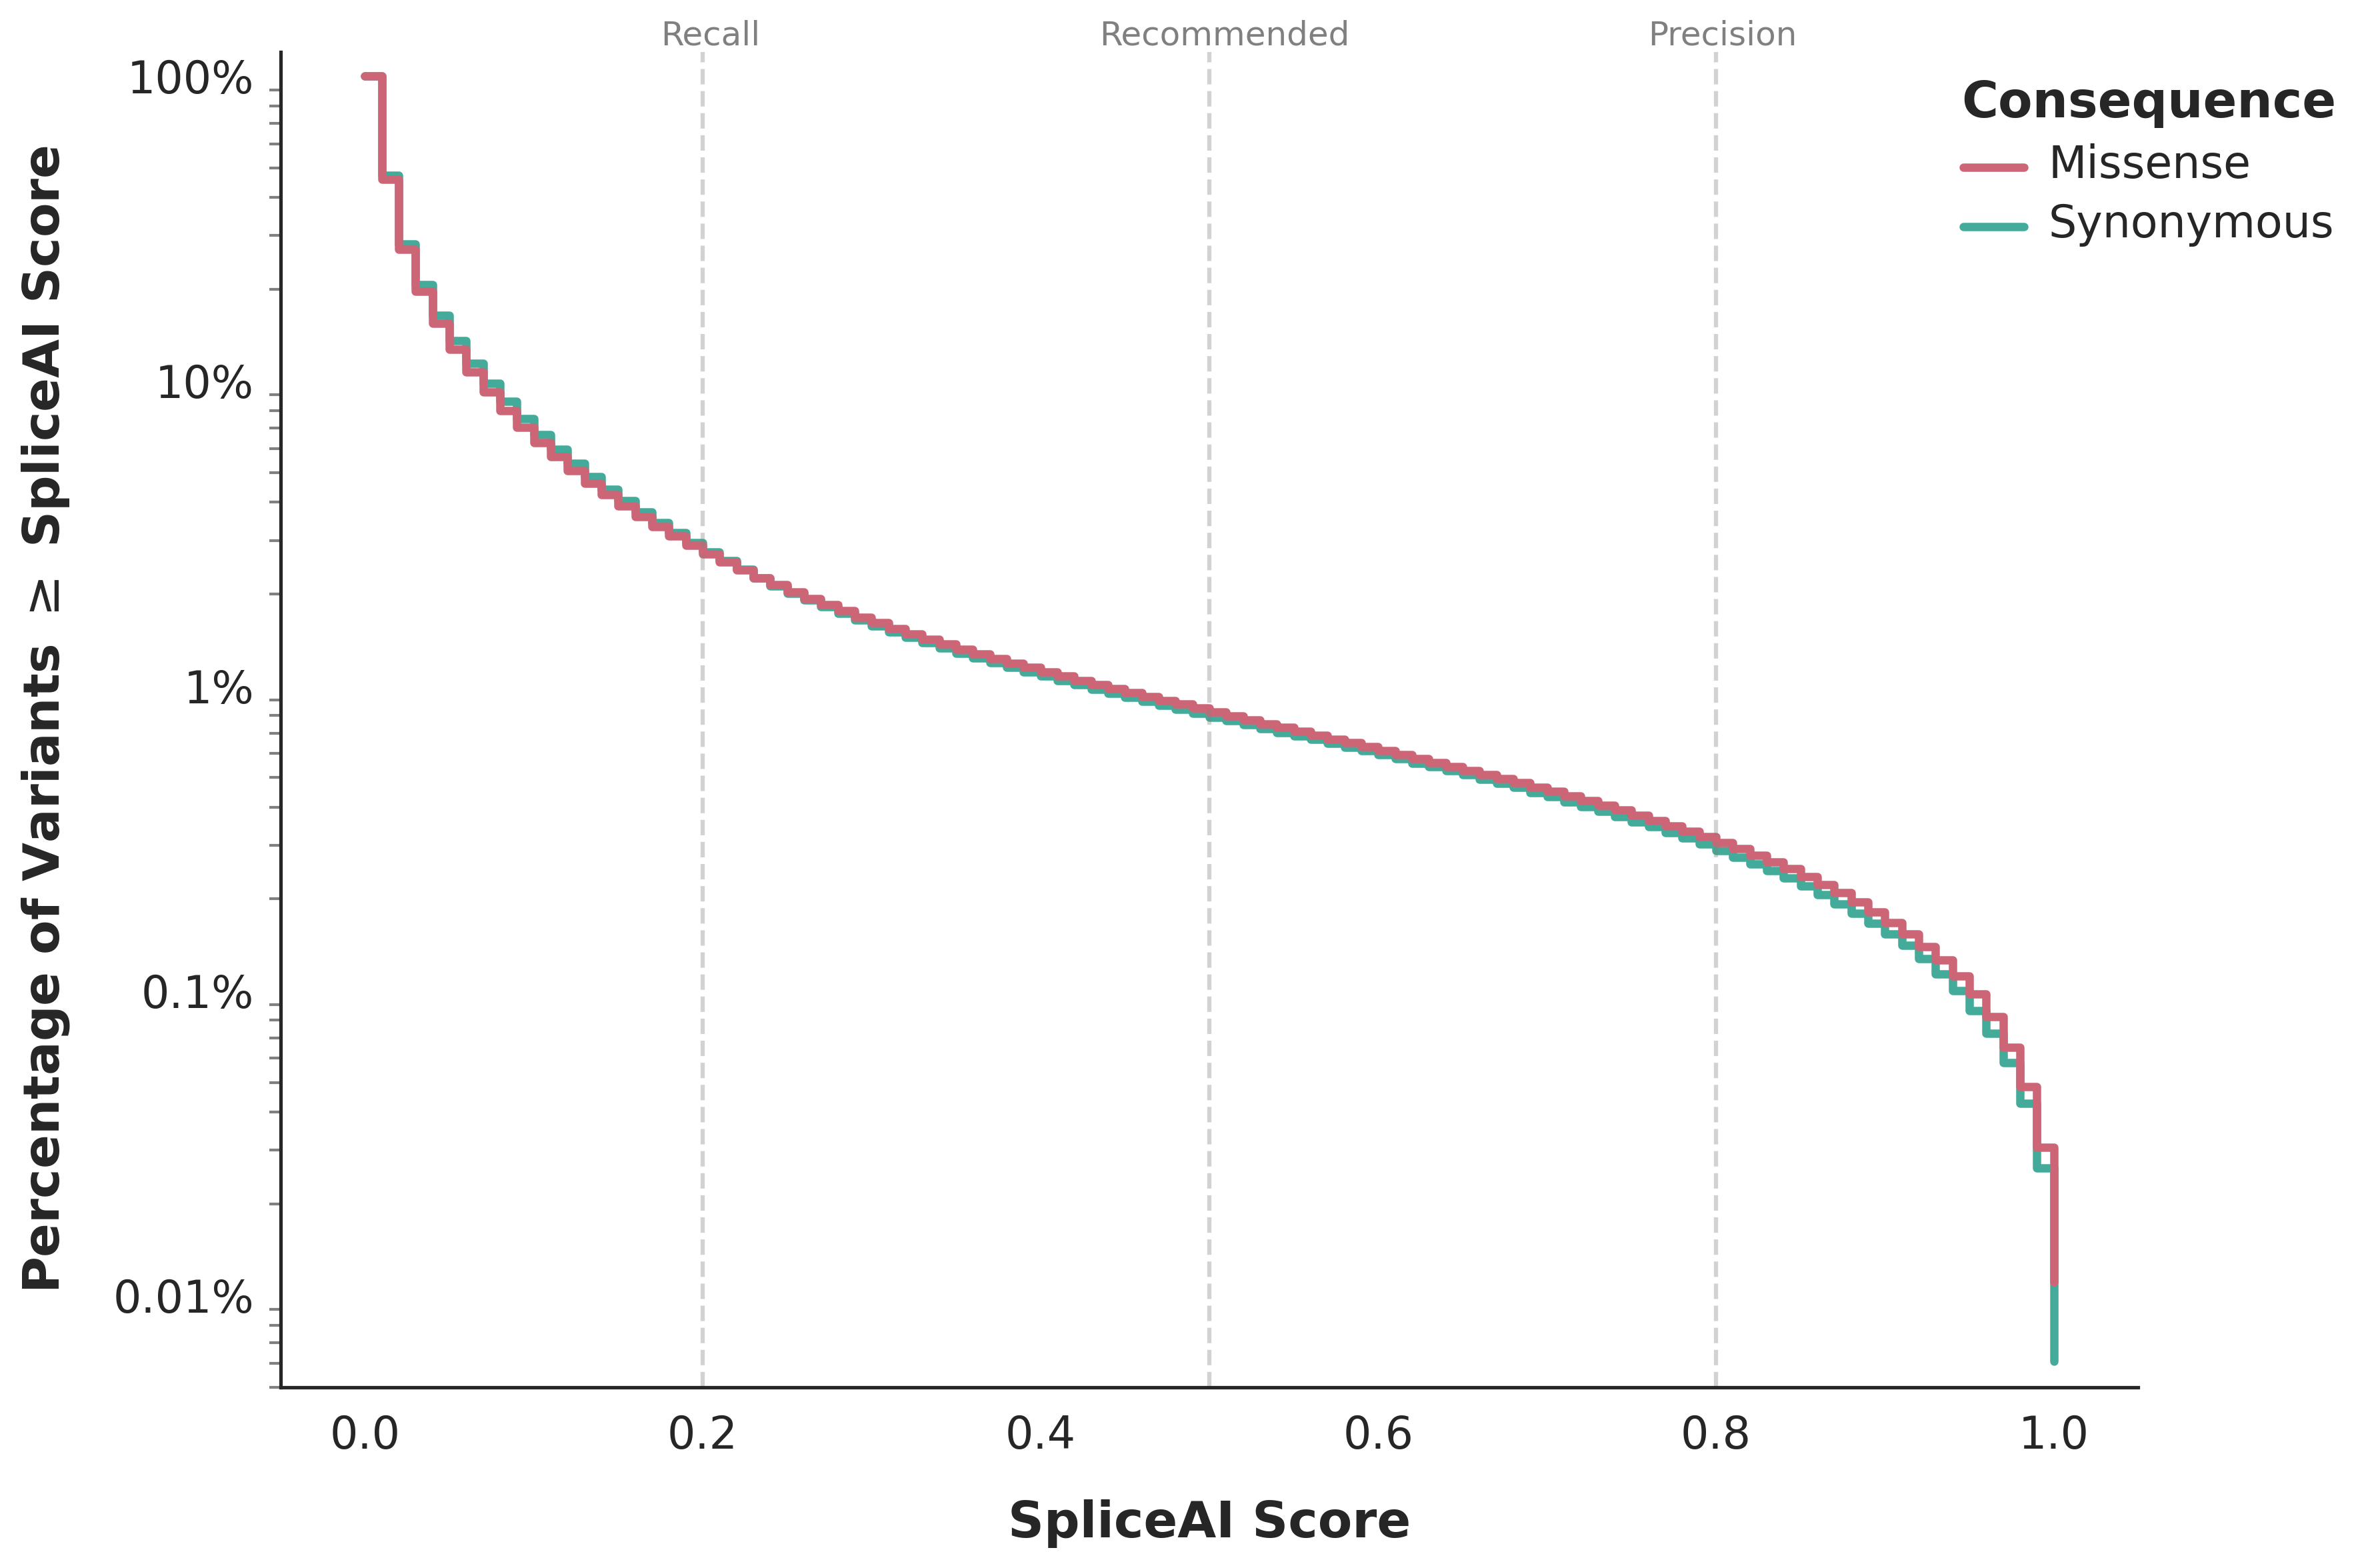

In [49]:
# Set Styling
sns.set_style('white') 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.autolayout'] = True

# Instantiate Figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot Synonymous Behind Missense
sns.lineplot(data=splice_counts_survival[splice_counts_survival['consequence'] == 'Synonymous'], 
             x='Max_SpliceAI_Score', y='cumulative_perc', 
             color='#44AA99', linewidth=3, 
             drawstyle='steps-post', ax=ax, label='Synonymous', zorder=1)

# Plot Missense After
sns.lineplot(data=splice_counts_survival[splice_counts_survival['consequence'] == 'Missense'], 
             x='Max_SpliceAI_Score', y='cumulative_perc', 
             color='#CC6677', linewidth=3, 
             drawstyle='steps-post', ax=ax, label='Missense', zorder=2)

# Formatting
ax.set_ylim(0.005, 120)
ax.set_yscale('log') 
ax.set_xlabel('SpliceAI Score', fontsize=18, fontweight='bold',
             labelpad=15)
ax.set_ylabel('Percentage of Variants $\geq$ SpliceAI Score', fontsize=18, fontweight='bold',
             labelpad=15)

# Major Ticks
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}%'))

# Minor Ticks
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=range(2,10), numticks=12))
ax.tick_params(axis='y', which='major', length=6, width=1.5, labelsize=16, direction='out', color='black')
ax.tick_params(axis='y', which='minor', length=4, width=1, color='grey', direction='out', left=True)
ax.tick_params(axis='x', which='major', length=6, width=1.5, labelsize=16, direction='out')

# Legend - ensuring Missense is shown first
handles, labels = ax.get_legend_handles_labels()
order = [labels.index('Missense'), labels.index('Synonymous')]
leg = ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
                loc='upper left', bbox_to_anchor=(0.89, 1))
plt.setp(leg.get_texts(), fontsize='16')
leg.set_title('Consequence')
plt.setp(leg.get_title(), fontsize='18', fontweight='bold')
leg.set_frame_on(False)

# Remove top and right spines
sns.despine()

# Add SpliceAI Thresholds
for threshold in [0.2, 0.5, 0.8]:
    ax.axvline(threshold, color='grey', linestyle='--', alpha=0.35,
              linewidth=1.5)

ax.text(0.175, ax.get_ylim()[1], 'Recall', color='grey', va='bottom', fontsize=12)
ax.text(0.435, ax.get_ylim()[1], 'Recommended', color='grey', va='bottom', fontsize=12)
ax.text(0.76, ax.get_ylim()[1], 'Precision', color='grey', va='bottom', fontsize=12)

# Save figure as PDF
#plt.savefig('/slade/home/mr935/figures/Spliceogenic_Missense/UKB_SpliceAI_Distributions_Consequence.pdf',
            #format='pdf', bbox_inches='tight', transparent=True, dpi=600)

plt.tight_layout()
plt.show()

## Figure S1 - Stratified MAF

In [56]:
# Set canonical order for AF Tiers
af_order = [
    'gnomAD Unobserved',
    '0 < AF <= 0.01% (Ultra-Rare)',
    '0.01% < AF <= 0.1% (Rare)',
    '0.1% < AF <= 1% (Low-Frequency)',
    'AF > 1% (Common)',
]

# Calculate total counts per AF_Tier and consequence
totals = (
    clean_mane.groupby(['AF_Tier', 'Consequence'])
    .size()
    .reset_index(name='total_count')
)

# Generate variant counts at each SpliceAI score
splice_counts = (
    clean_mane.groupby(['AF_Tier', 'Consequence', 'Max_SpliceAI_Score'])
    .size()
    .reset_index(name='counts')
)

# Merge totals to compute proportions per tier
splice_counts = pd.merge(splice_counts, totals, on=['AF_Tier', 'Consequence'])
splice_counts['proportion'] = (
    splice_counts['counts'] / splice_counts['total_count']
)

# Compute cumulative percentages per AF Tier & Consequence
splice_counts_survival = splice_counts.sort_values(
    ['AF_Tier', 'Consequence', 'Max_SpliceAI_Score'], ascending=[True, True, False]
)
splice_counts_survival['cumulative_perc'] = (
    splice_counts_survival.groupby(['AF_Tier', 'Consequence'])[
        'proportion'
    ].cumsum()
    * 100
)

# Categorical formatting for drawing order and layout
splice_counts_survival['Consequence'] = pd.Categorical(
    splice_counts_survival['Consequence'],
    categories=['synonymous', 'missense'],
    ordered=True,
)

/tmp/ipykernel_2282160/947217748.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_mane.groupby(['AF_Tier', 'Consequence'])
/tmp/ipykernel_2282160/947217748.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_mane.groupby(['AF_Tier', 'Consequence', 'Max_SpliceAI_Score'])
/tmp/ipykernel_2282160/947217748.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  splice_counts_survival.groupby(['AF_Tier', 'Conseq

In [57]:
splice_counts.head()

,AF_Tier,Consequence,Max_SpliceAI_Score,counts,total_count,proportion
0,gnomAD Unobserved,missense,0.00,3230377,5947473,0.543151
1,gnomAD Unobserved,missense,0.01,1118432,5947473,0.188052
2,gnomAD Unobserved,missense,0.02,435208,5947473,0.073175
3,gnomAD Unobserved,missense,0.03,247448,5947473,0.041606
4,gnomAD Unobserved,missense,0.04,163857,5947473,0.027551


In [58]:
splice_counts_survival.head()

,AF_Tier,Consequence,Max_SpliceAI_Score,counts,total_count,proportion,cumulative_perc
100,gnomAD Unobserved,missense,1.00,761,5947473,0.000128,0.012795
99,gnomAD Unobserved,missense,0.99,1264,5947473,0.000213,0.034048
98,gnomAD Unobserved,missense,0.98,1146,5947473,0.000193,0.053317
97,gnomAD Unobserved,missense,0.97,1058,5947473,0.000178,0.071106
96,gnomAD Unobserved,missense,0.96,1123,5947473,0.000189,0.089988


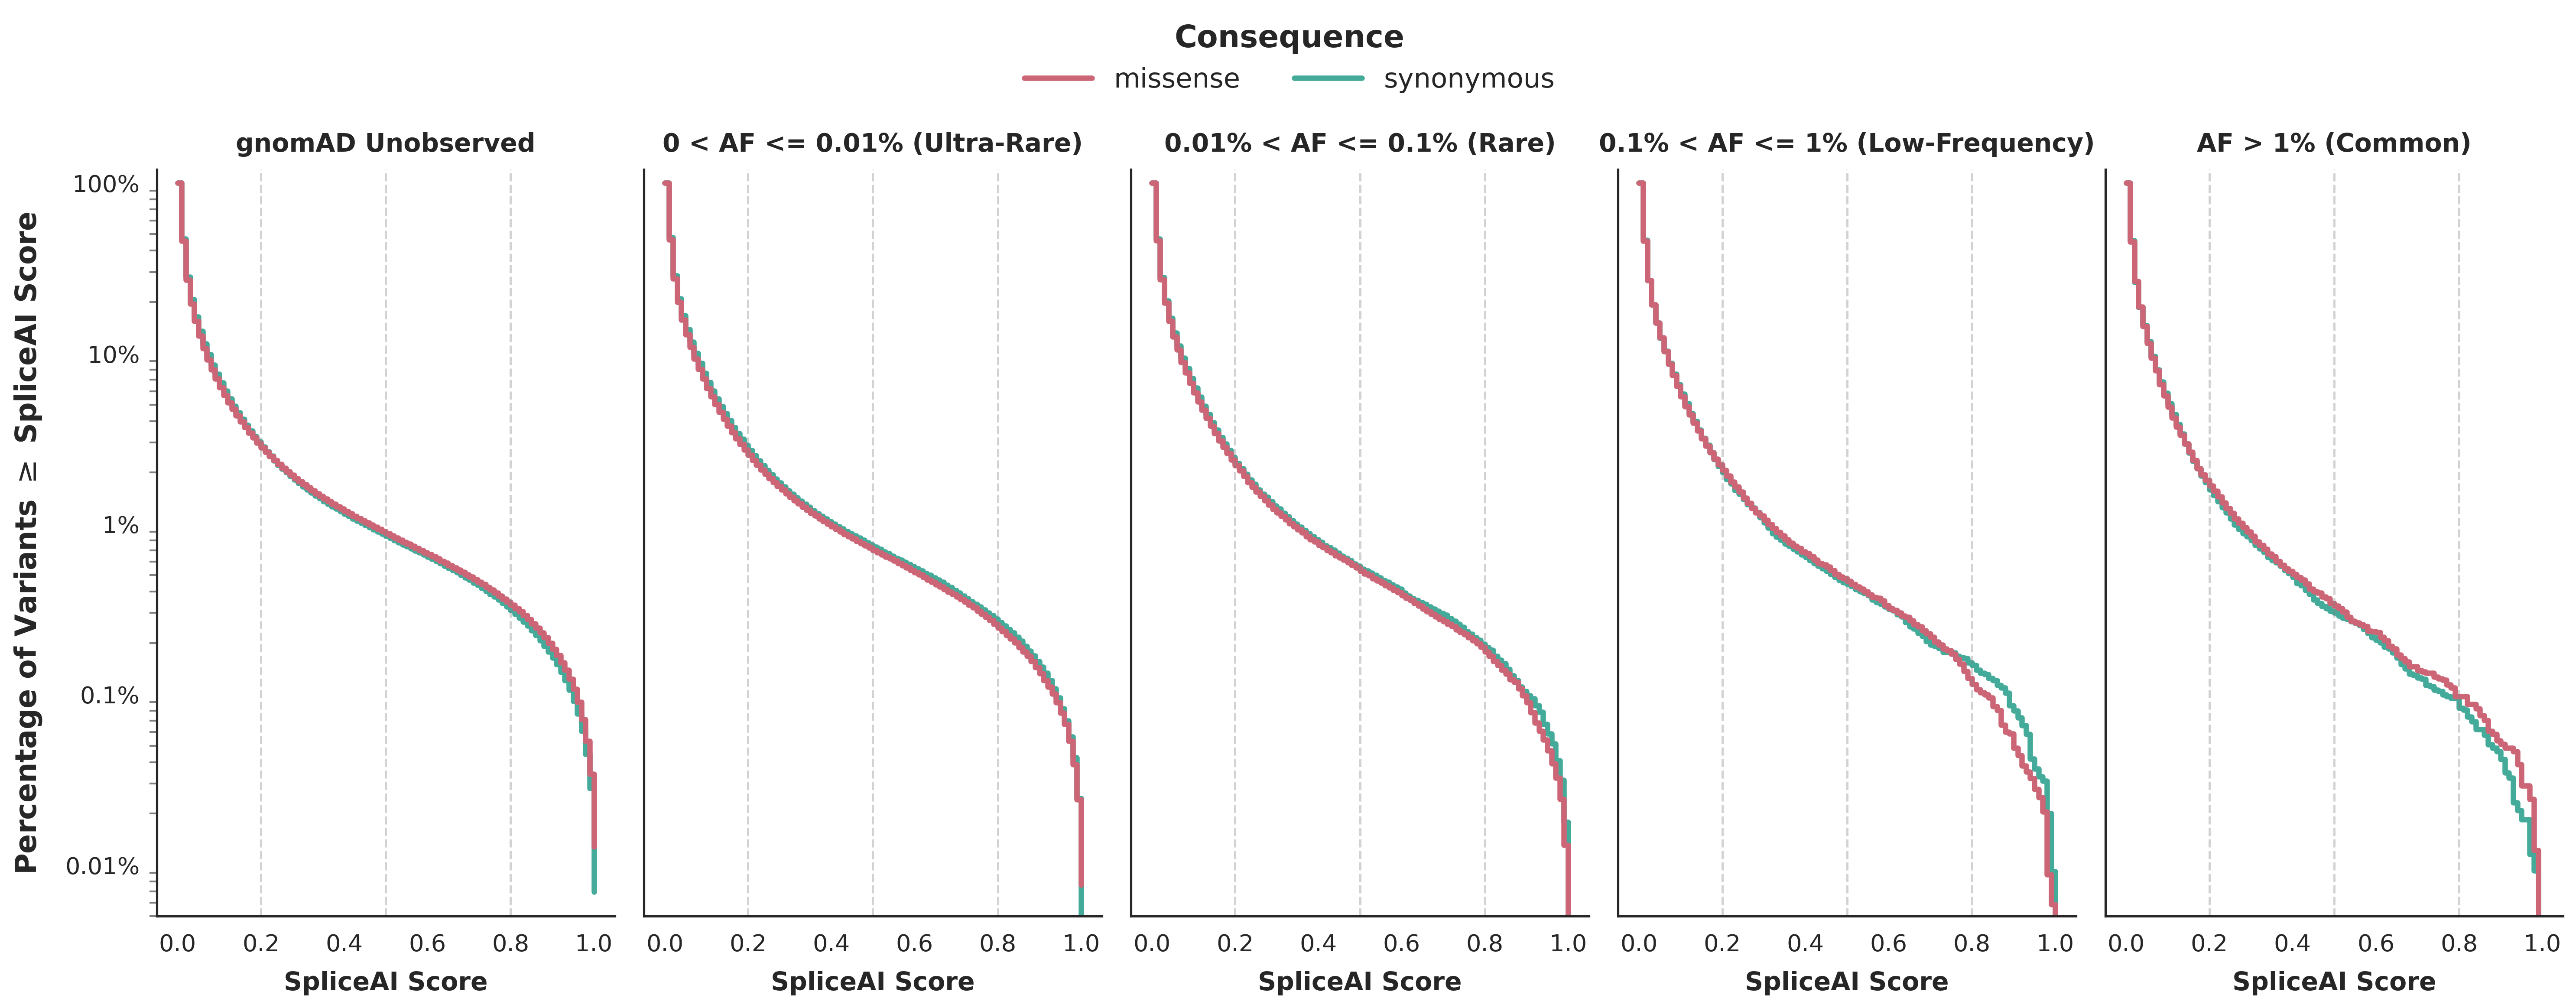

In [59]:
# Plotting Setup
sns.set_style('white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300

# Create subplot layout
fig, axes = plt.subplots(1, 5, figsize=(20, 7), sharey=True, sharex=True)

for i, tier in enumerate(af_order):
    ax = axes[i]
    tier_data = splice_counts_survival[
        splice_counts_survival['AF_Tier'] == tier
    ]

    # Synonymous (zorder=1, plotted behind)
    sns.lineplot(
        data=tier_data[tier_data['Consequence'] == 'synonymous'],
        x='Max_SpliceAI_Score',
        y='cumulative_perc',
        color='#44AA99',
        linewidth=3,
        drawstyle='steps-post',
        ax=ax,
        label='synonymous',
        zorder=1,
    )

    # Missense (zorder=2, plotted in front)
    sns.lineplot(
        data=tier_data[tier_data['Consequence'] == 'missense'],
        x='Max_SpliceAI_Score',
        y='cumulative_perc',
        color='#CC6677',
        linewidth=3,
        drawstyle='steps-post',
        ax=ax,
        label='missense',
        zorder=2,
    )

    # Formatting axes and titles
    ax.set_ylim(0.005, 120)
    ax.set_yscale('log')
    ax.set_title(tier, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('SpliceAI Score', fontsize=14, fontweight='bold', labelpad=8)

    # Add SpliceAI threshold lines
    for threshold in [0.2, 0.5, 0.8]:
        ax.axvline(
            threshold, color='grey', linestyle='--', alpha=0.35, linewidth=1.2
        )

    # Remove individual legends
    if ax.get_legend():
        ax.get_legend().remove()

    sns.despine(ax=ax)

ax_first = axes[0]

# Y-axis label
ax_first.set_ylabel(
    'Percentage of Variants $\geq$ SpliceAI Score',
    fontsize=16,
    fontweight='bold',
    labelpad=12,
)

# Major & Minor Log Ticks
ax_first.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax_first.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'{y:g}%')
)
ax_first.yaxis.set_minor_locator(
    ticker.LogLocator(base=10.0, subs=range(2, 10), numticks=12)
)

# Apply explicit tick styles to the primary y-axis
ax_first.tick_params(axis='y', which='major', length=6,
    width=1.5, labelsize=13, direction='out', color='black')

ax_first.tick_params(axis='y', which='minor', length=4,
    width=1, color='grey', direction='out', left=True)

# Set x-axis tick params across all panels
for ax in axes:
    ax.tick_params(
        axis='x', which='major', length=6, width=1.5, labelsize=13, direction='out'
    )

# Single combined top legend
handles, labels = axes[0].get_legend_handles_labels()
order = [labels.index('missense'), labels.index('synonymous')]
fig.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncols=2,
    frameon=False,
    fontsize=15,
    handlelength=2.5,
    title='Consequence',
    title_fontproperties={'size': 17, 'weight': 'bold'}
)

plt.tight_layout()
plt.show()

## B) Splice-Junction Distance

In [ ]:
missense_300 = missense[missense['Variant_Canonical_Splice_Distance'] <= 300]

In [61]:
missense_300.head()

,variantID,Gene,SYMBOL,Strand,Max_SpliceAI_Score,Max_SpliceAI_Column,Max_SpliceAI_Position,Variant_Canonical_Splice_Distance,Feature,VEP_Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,CCDS,SWISSPROT,UNIPROT_ISOFORM,GENE_PHENO,SIFT,PolyPhen,EXON,HGVSc,HGVSp,MAX_AF,MAX_AF_POPS,CLIN_SIG,CADD_PHRED,CADD_RAW,REVEL,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,SpliceAI_DS_AG,SpliceAI_DS_AL,SpliceAI_DS_DG,SpliceAI_DS_DL,SpliceAI_DP_AG,SpliceAI_DP_AL,SpliceAI_DP_DG,SpliceAI_DP_DL,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,Consequence
0,chr1-65568-A-C,ENSG00000186092,OR4F5,+,0.04,SpliceAI_DS_DL,5.0,5,ENST00000641515,missense_variant,64,4,2,K/Q,Aag/Cag,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.06),benign(0),2/3,ENST00000641515.2:c.4A>C,ENSP00000493376.2:p.Lys2Gln,NaN,None,None,18.990,1.964888,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.01,0.04,298.0,321.0,-135.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
1,chr1-65568-A-G,ENSG00000186092,OR4F5,+,0.02,SpliceAI_DS_DL,5.0,5,ENST00000641515,missense_variant,64,4,2,K/E,Aag/Gag,None,MODERATE,CCDS30547.2,None,None,NaN,deleterious_low_confidence(0.04),benign(0),2/3,ENST00000641515.2:c.4A>G,ENSP00000493376.2:p.Lys2Glu,NaN,None,None,19.220,1.994556,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.01,0.02,298.0,-48.0,-135.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
2,chr1-65571-A-C,ENSG00000186092,OR4F5,+,0.00,SpliceAI_DS_AG,295.0,2,ENST00000641515,"missense_variant,splice_region_variant",67,7,3,K/Q,Aag/Cag,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.47),benign(0.027),2/3,ENST00000641515.2:c.7A>C,ENSP00000493376.2:p.Lys3Gln,NaN,None,None,16.030,1.545987,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.00,0.00,0.00,0.00,295.0,-51.0,2.0,-138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
3,chr1-69037-G-T,ENSG00000186092,OR4F5,+,0.19,SpliceAI_DS_AG,10.0,0,ENST00000641515,"missense_variant,splice_region_variant",70,10,4,V/L,Gta/Tta,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.12),benign(0.018),3/3,ENST00000641515.2:c.10G>T,ENSP00000493376.2:p.Val4Leu,NaN,None,None,12.030,1.032664,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.19,0.17,0.01,0.00,10.0,0.0,56.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense
4,chr1-69038-T-C,ENSG00000186092,OR4F5,+,0.03,SpliceAI_DS_AL,-1.0,1,ENST00000641515,"missense_variant,splice_region_variant",71,11,4,V/A,gTa/gCa,None,MODERATE,CCDS30547.2,None,None,NaN,tolerated_low_confidence(0.3),benign(0),3/3,ENST00000641515.2:c.11T>C,ENSP00000493376.2:p.Val4Ala,NaN,None,None,7.806,0.630509,NaN,None,NaN,None,NaN,NaN,0.0,0.34887,1.828,False,0.02,0.03,0.00,0.00,9.0,-1.0,55.0,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,missense


In [62]:
# Determine percentage of high splice variants by splice junction distance
missense_summary = missense_300.groupby('Variant_Canonical_Splice_Distance').agg(
    total_variants=('Max_SpliceAI_Score', 'size'), # Number of variants in bin
    high_score_variants=('Max_SpliceAI_Score', lambda x: (x >= 0.2).sum())
)

missense_summary['high_score_percentage'] = 100 * missense_summary['high_score_variants'] / missense_summary['total_variants']
missense_summary = missense_summary.reset_index()

In [63]:
missense_summary.head()

,Variant_Canonical_Splice_Distance,total_variants,high_score_variants,high_score_percentage
0,0,91241,37383,40.971712
1,1,74662,13598,18.212745
2,2,75247,7783,10.343269
3,3,77453,5883,7.595574
4,4,78338,4361,5.566902


In [64]:
# Start dataset from variants 5 or more bases away from a splice junction to 
# visually capture exponential relationship better
missense_summary_data = missense_summary.iloc[5:]
missense_summary_data = missense_summary_data[missense_summary_data['Variant_Canonical_Splice_Distance'] < 300]

In [65]:
missense_summary_data.head(25)

,Variant_Canonical_Splice_Distance,total_variants,high_score_variants,high_score_percentage
5,5,79291,2954,3.725517
6,6,80296,2763,3.441018
7,7,78730,2841,3.608536
8,8,79789,2596,3.253581
9,9,80423,2461,3.060070
10,10,79655,2643,3.318059
11,11,80713,2679,3.319168
12,12,79135,2472,3.123776
13,13,78066,2512,3.217790
14,14,79797,2608,3.268293


In [66]:
sum(missense_summary_data.iloc[:18]['high_score_variants'].to_list())

47736

In [67]:
sum(missense_summary_data.iloc[:18]['total_variants'].to_list())

1429930

In [68]:
47736 / 1429930 * 100

3.3383452336827677

In [69]:
sum(missense_summary_data.iloc[:15]['high_score_variants'].to_list()) / sum(missense_summary_data.iloc[:15]['total_variants'].to_list()) * 100

3.350980214712103

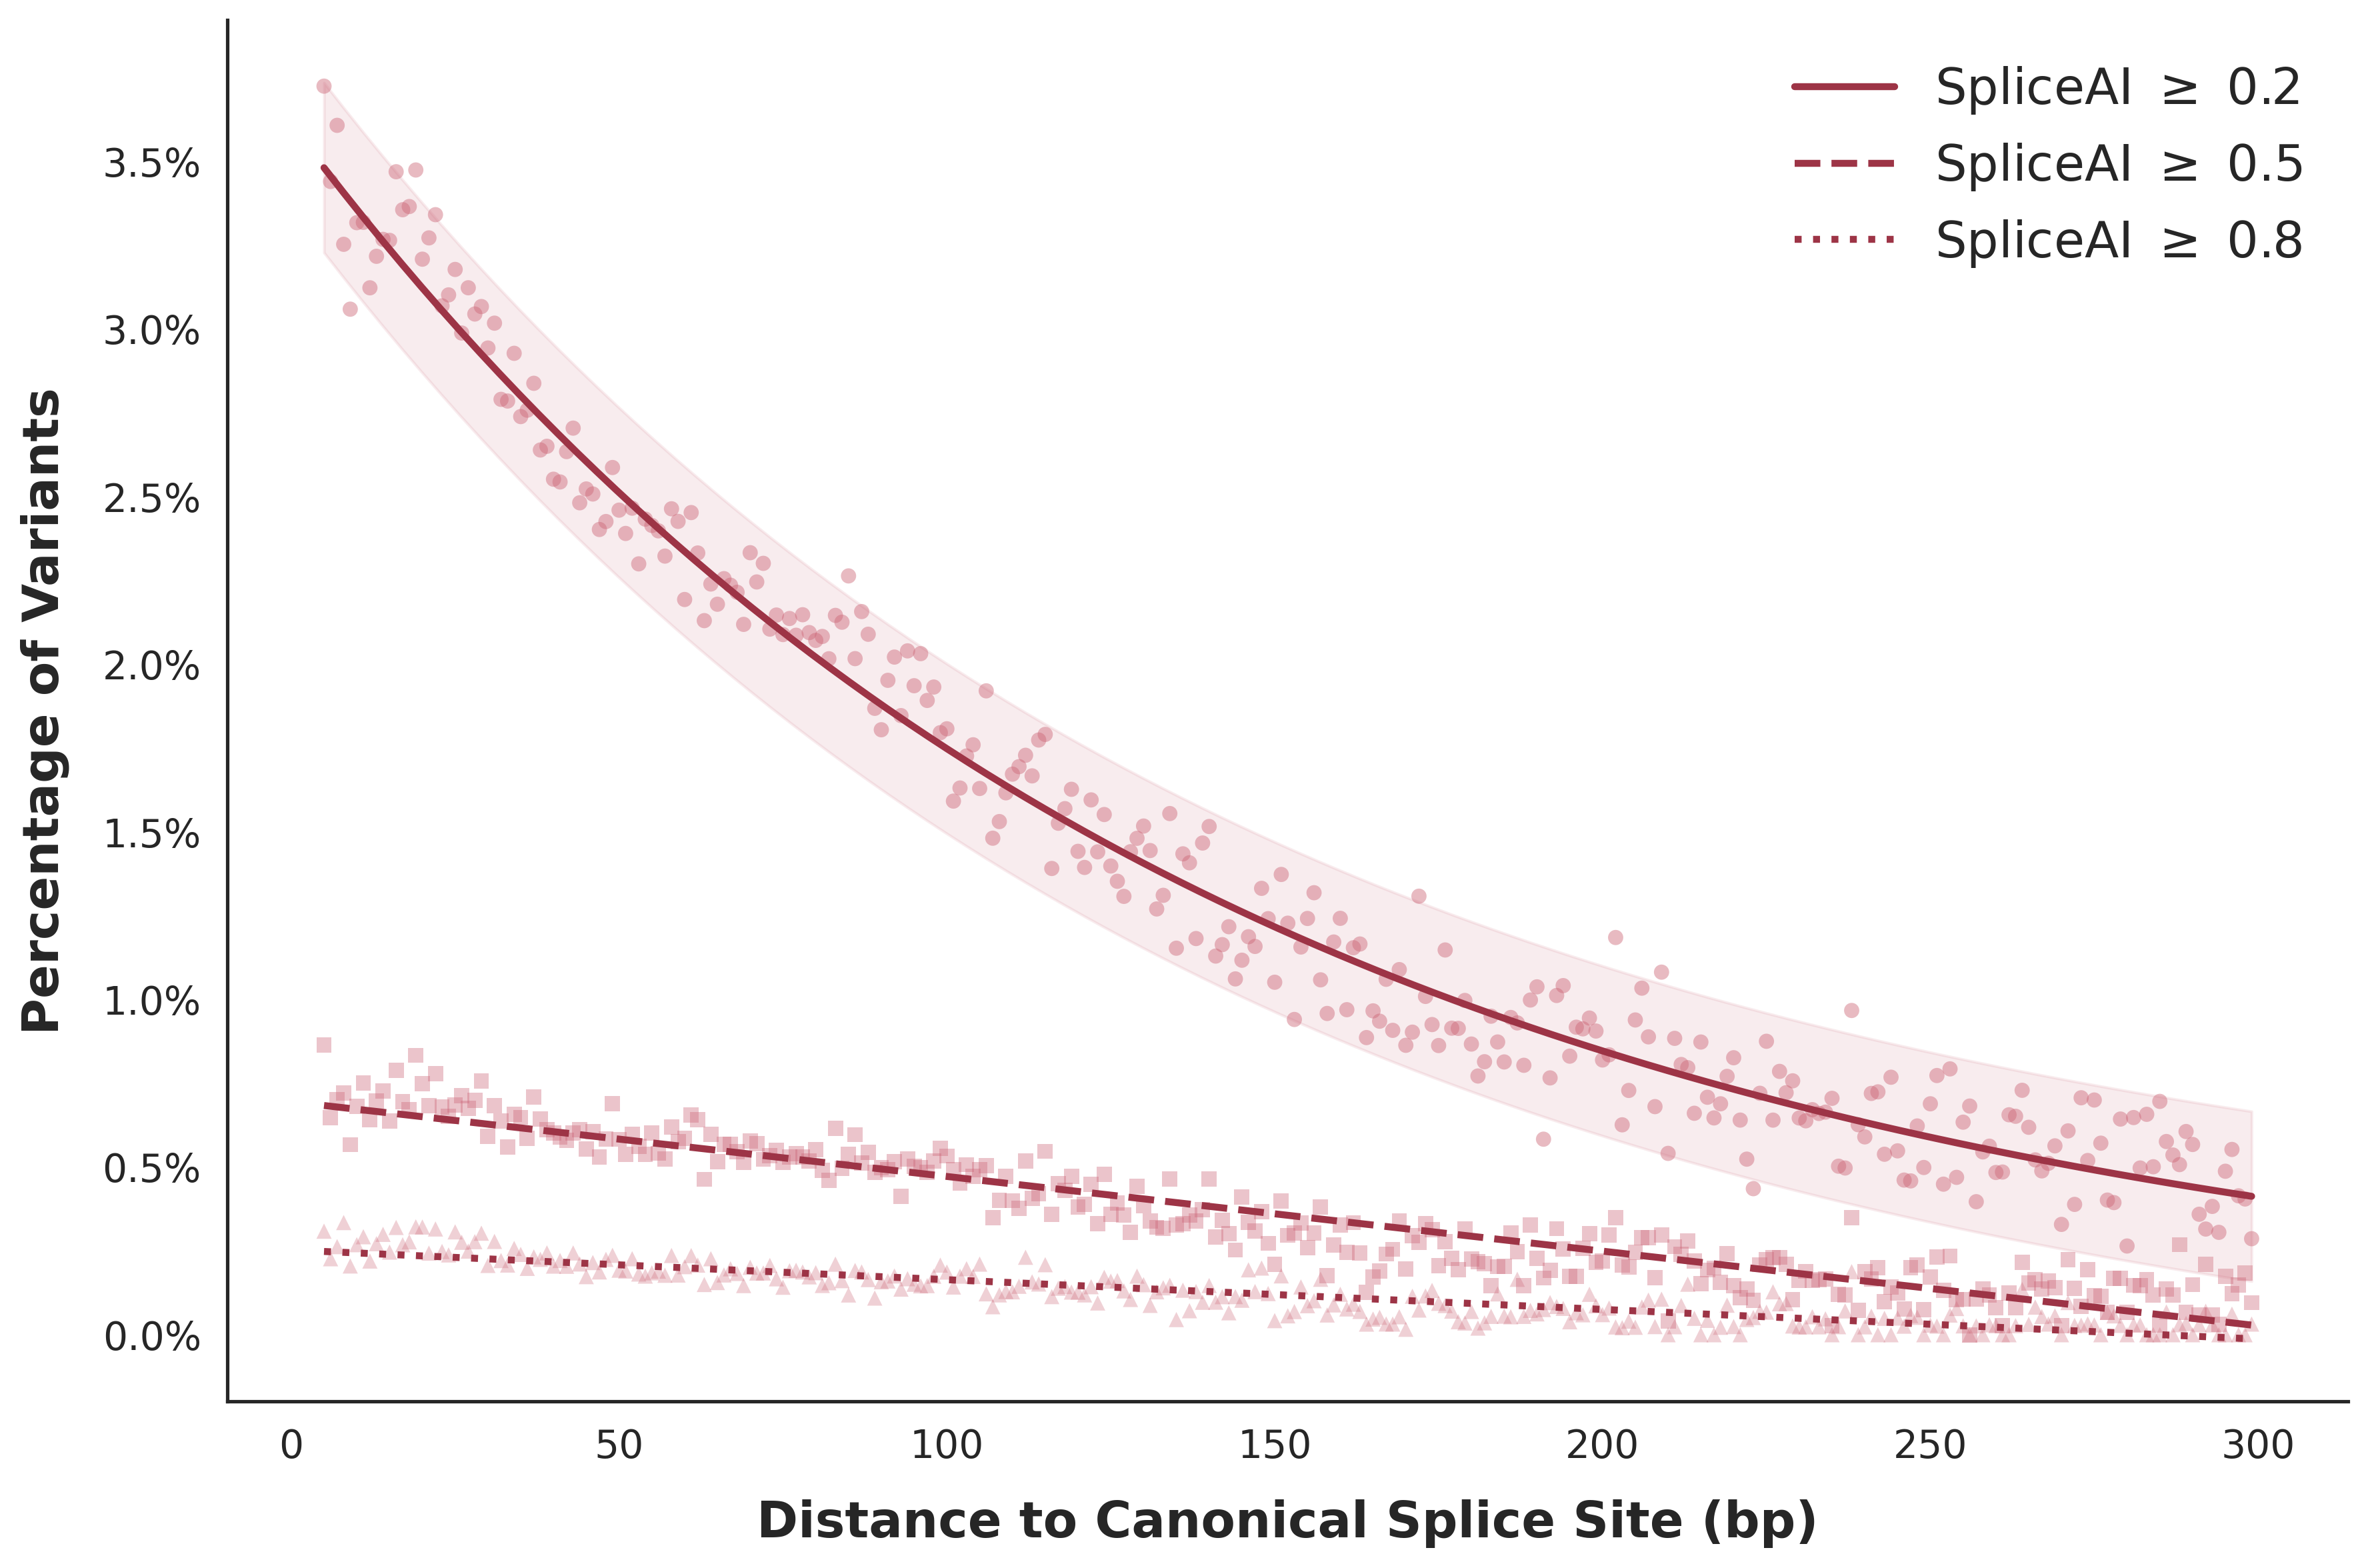

In [71]:
# Configuration
base_color = '#CC6677' 
dark_color = '#9D3446' 

threshold_configs = {
    0.2: {'marker': 'o', 'linestyle': '-', 'fit': 'exp',
          'point_alpha': 0.45, 'alpha': 0.12, 'show_band': True},
    0.5: {'marker': 's', 'linestyle': '--', 'fit': 'linear',
          'point_alpha': 0.38, 'alpha': 0.1, 'show_band': False},
    0.8: {'marker': '^', 'linestyle': ':', 'fit': 'linear',
          'point_alpha': 0.3, 'alpha': 0.08, 'show_band': False}
}

sns.set_style('white')
fig, ax = plt.subplots(figsize=(12, 8))

for t, config in threshold_configs.items():
    summary = missense_300.groupby('Variant_Canonical_Splice_Distance').agg(
        total_variants=('Max_SpliceAI_Score', 'size'),
        high_score_variants=('Max_SpliceAI_Score', lambda x: (x >= t).sum())
    )
    summary['perc'] = 100 * summary['high_score_variants'] / summary['total_variants']
    data = summary.iloc[5:].reset_index()
    data = data[data['Variant_Canonical_Splice_Distance'] < 300]
    
    dist = data['Variant_Canonical_Splice_Distance']
    perc = data['perc']
    dist_fit = np.linspace(dist.min(), dist.max(), 100)

    # Modelling 
    if config['fit'] == 'exp':
        log_perc = np.log(perc + 1e-6) 
        coeffs = np.polyfit(dist, log_perc, 1)
        perc_fit = np.exp(coeffs[1]) * np.exp(coeffs[0] * dist_fit)
        perc_pred_for_resid = np.exp(coeffs[1]) * np.exp(coeffs[0] * dist)
    else:
        coeffs = np.polyfit(dist, perc, 1)
        perc_fit = coeffs[0] * dist_fit + coeffs[1]
        perc_pred_for_resid = coeffs[0] * dist + coeffs[1]

    # Uncertainty 
    if config['show_band']:
        std_resid = np.std(perc - perc_pred_for_resid)
        ax.fill_between(dist_fit, perc_fit - (2 * std_resid), perc_fit + (2 * std_resid), 
                        color=base_color, alpha=config['alpha'], zorder=1)

    # Visualization 
    ax.scatter(dist, perc, color=base_color, alpha=config['point_alpha'], s=30, 
               marker=config['marker'], edgecolor='none', zorder=2)
    
    ax.plot(dist_fit, perc_fit, color=dark_color, linewidth=2.5, 
            linestyle=config['linestyle'], label=f'SpliceAI $\geq$ {t}', zorder=3)

# Formatting 
ax.set_xlabel('Distance to Canonical Splice Site (bp)', fontsize=18, fontweight='bold', labelpad=12)
ax.set_ylabel('Percentage of Variants', fontsize=18, fontweight='bold', labelpad=12)

ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(frameon=False, fontsize=18, loc='upper right')

sns.despine()

# Save figure as PDF
#plt.savefig('/slade/home/mr935/figures/Spliceogenic_Missense/SpliceAI_Junction_Distance_Plot.pdf',
 #          format='pdf', bbox_inches='tight', transparent=True, dpi=600)

plt.tight_layout()

plt.show()

### Make Supp Figures for Missense Variants - S3

In [72]:
# Make datasets by predicted splice event
donor_gains = missense_300[missense_300['Max_SpliceAI_Column'] == 'SpliceAI_DS_DG'].copy()
acceptor_gains = missense_300[missense_300['Max_SpliceAI_Column'] == 'SpliceAI_DS_AG'].copy()
donor_losses = missense_300[missense_300['Max_SpliceAI_Column'] == 'SpliceAI_DS_DL'].copy()
acceptor_losses = missense_300[missense_300['Max_SpliceAI_Column'] == 'SpliceAI_DS_AL'].copy()

In [74]:
all_splice = pd.read_parquet("/slade/home/mr935/scripts/biobank_work/parquets/clean_mane-all_splice.parquet")

In [79]:
all_splice.head()

,#Uploaded_variation,Location,Allele,Gene,Feature,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,VARIANT_CLASS,SYMBOL,SYMBOL_SOURCE,HGNC_ID,BIOTYPE,CANONICAL,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SOURCE,GENE_PHENO,SIFT,PolyPhen,EXON,INTRON,DOMAINS,miRNA,HGVSc,HGVSp,HGVS_OFFSET,AF,AFR_AF,AMR_AF,EAS_AF,EUR_AF,SAS_AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_NFE_AF,gnomADe_OTH_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_OTH_AF,gnomADg_SAS_AF,MAX_AF,MAX_AF_POPS,CLIN_SIG,SOMATIC,PHENO,PUBMED,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,CADD_PHRED,CADD_RAW,Conservation,SpliceAI_pred,REVEL,LoF,LoF_filter,LoF_flags,LoF_info,existing_InFrame_oORFs,existing_OutOfFrame_oORFs,existing_uORFs,five_prime_UTR_variant_annotation,five_prime_UTR_variant_consequence,am_class,am_pathogenicity,EVE_CLASS,EVE_SCORE,PrimateAI,SpliceRegion,riboseq_orf,constraint_z_region,phast_cons_30way_region,phast_cons_30way_lod,phast_cons_30way_score,phast_cons_100way_region,phast_cons_100way_lod,phast_cons_100way_score,jarvis_score,jarvis_score_percentile,gene,gene_id,lof.oe,lof.pLI,lof.oe_ci.upper,high_pLI,Chromosome,Position,Strand,Start,End,Distance_Donor,Start_b_Donor,End_b_Donor,Distance_Acceptor,Start_b_Acceptor,End_b_Acceptor,Nearest_Site
0,1:65568:A:C,chr1:65568,C,ENSG00000186092,ENST00000641515,missense_variant,64,4,2,K/Q,Aag/Cag,None,MODERATE,NaN,1,NaN,SNV,OR4F5,HGNC,HGNC:14825,protein_coding,YES,NM_001005484.2,NaN,NaN,P1,CCDS30547.2,ENSP00000493376,None,A0A2U3U0J3.19,UPI000D1938F0,None,NaN,NaN,tolerated_low_confidence(0.06),benign(0),2/3,NaN,AlphaFold_DB_import:AF-A0A2U3U0J3-F1,NaN,ENST00000641515.2:c.4A>C,ENSP00000493376.2:p.Lys2Gln,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,nan,NaN,NaN,NaN,NaN,NaN,18.990,1.964888,3.230,SpliceAI=C|ENST00000641515.2|0.00|0.00|0.01|0.04|298|321|-135|5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,None,None,chr1_65554_65584,27.0,348.0,chr1_65562_65579,43.0,366.0,NaN,NaN,OR4F5,ENSG00000186092,0.0,0.34887,1.828,False,chr1,65568,+,65567,65568,6,65573,65574,48,65519,65520,Donor
1,1:65568:A:G,chr1:65568,G,ENSG00000186092,ENST00000641515,missense_variant,64,4,2,K/E,Aag/Gag,None,MODERATE,NaN,1,NaN,SNV,OR4F5,HGNC,HGNC:14825,protein_coding,YES,NM_001005484.2,NaN,NaN,P1,CCDS30547.2,ENSP00000493376,None,A0A2U3U0J3.19,UPI000D1938F0,None,NaN,NaN,deleterious_low_confidence(0.04),benign(0),2/3,NaN,AlphaFold_DB_import:AF-A0A2U3U0J3-F1,NaN,ENST00000641515.2:c.4A>G,ENSP00000493376.2:p.Lys2Glu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,nan,NaN,NaN,NaN,NaN,NaN,19.220,1.994556,3.230,SpliceAI=G|ENST00000641515.2|0.00|0.00|0.01|0.02|298|-48|-135|5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,NaN,NaN,NaN,None,None,chr1_65554_65584,27.0,348.0,chr1_65562_65579,43.0,366.0,NaN,NaN,OR4F5,ENSG00000186092,0.0,0.34887,1.828,False,chr1,65568,+,65567,65568,6,65573,65574,48,65519,65520,Donor
2,1:65571:A:C,chr1:65571,C,ENSG00000186092,ENST00000641515,"missense_variant,splice_region_variant",67,7,3,K/Q,Aag/Cag,None,MODERATE,NaN,1,NaN,SNV,OR4F5,HGNC,HGNC:14825,protein_coding,YES,NM_001005484.2,NaN,NaN,P1,CCDS30547.2,ENSP00000493376,None,A0A2U3U0J3.19,UPI000D1938F0,None,NaN,NaN,tolerated_low_confidence(0.47),benign(0.027),2/3,NaN,AlphaFold_DB_import:AF-A0A2U3U0J3-F1,NaN,ENST00000641515.2:c.7A>C,ENSP00000493376.2:p.Lys3Gln,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,nan,NaN,NaN,NaN,NaN,NaN,16.030,1.545987,0.430,SpliceAI=C|ENST00000641515.2|0.00|0.00|0.

In [80]:
missense_300['#Uploaded_variation'] = missense_300['variantID'].apply(lambda row: row.replace('chr', '').replace('-', ':'))

In [81]:
# Get nearest splice site for variants
all_splice_cols = all_splice[['#Uploaded_variation', 'Nearest_Site']]

all_splice_cols.set_index('#Uploaded_variation', inplace=True)
missense_300.set_index('#Uploaded_variation', inplace=True)

missense_300 = missense_300.join(
    all_splice_cols,
    how='left'
)

missense_300.reset_index(inplace=True)

In [82]:
donors = missense_300[missense_300['Nearest_Site'] == 'Donor']
acceptors = missense_300[missense_300['Nearest_Site'] == 'Acceptor']

In [83]:
donor_summary = donors.groupby('Variant_Canonical_Splice_Distance').agg(
    total_variants=('Max_SpliceAI_Score', 'size'), # Number of variants in bin (SpliceAI score column is arbitrary, any col can be picked)
    high_score_variants=('Max_SpliceAI_Score', lambda x: (x >= 0.2).sum())
)

donor_summary['high_score_percentage'] = 100 * donor_summary['high_score_variants'] / donor_summary['total_variants']
donor_summary = donor_summary.reset_index()

acceptor_summary = acceptors.groupby('Variant_Canonical_Splice_Distance').agg(
    total_variants=('Max_SpliceAI_Score', 'size'), # Number of variants in bin (SpliceAI score column is arbitrary, any col can be picked)
    high_score_variants=('Max_SpliceAI_Score', lambda x: (x >= 0.2).sum())
)

acceptor_summary['high_score_percentage'] = 100 * acceptor_summary['high_score_variants'] / donor_summary['total_variants']
acceptor_summary = acceptor_summary.reset_index()

In [90]:
donor_summary.head(10)

,Variant_Canonical_Splice_Distance,total_variants,high_score_variants,high_score_percentage
0,0,42946,26193,60.990546
1,1,40042,10399,25.970231
2,2,40755,4599,11.284505
3,3,33051,2307,6.980122
4,4,39323,1961,4.986903
5,5,44435,1397,3.143918
6,6,34498,962,2.788567
7,7,38969,1159,2.974159
8,8,44846,1354,3.019221
9,9,35516,1047,2.947967


In [91]:
acceptor_summary.head(10)

,Variant_Canonical_Splice_Distance,total_variants,high_score_variants,high_score_percentage
0,0,48295,11190,26.055977
1,1,34620,3199,7.989111
2,2,34492,3184,7.812538
3,3,44402,3576,10.819642
4,4,39015,2400,6.103298
5,5,34856,1557,3.503995
6,6,45798,1801,5.220592
7,7,39761,1682,4.316251
8,8,34943,1242,2.769478
9,9,44907,1414,3.981304


In [86]:
site_summary = pd.merge(
    donor_summary.head(25),
    acceptor_summary.head(25),
    left_index=True,
    right_index=True,
    how='inner',
    suffixes=('_donor', '_acceptor')
)

In [87]:
sites = site_summary.melt(
    id_vars=['Variant_Canonical_Splice_Distance_donor'],
    value_vars=['high_score_percentage_donor', 'high_score_percentage_acceptor'],
    var_name='Site',
    value_name='High_Score_Percentage'
)

sites['Site'] = sites['Site'].str.replace('high_score_percentage_', '').str.title()

sites.rename(columns={'Variant_Canonical_Splice_Distance_donor': 'Variant_Canonical_Splice_Distance'}, inplace=True)

In [88]:
distances = site_summary[site_summary['Variant_Canonical_Splice_Distance_donor'] < 5]['Variant_Canonical_Splice_Distance_donor'].unique()

# Initialise list to store comp. pairs + p.vals
comp_pairs = []
p_vals = []

# Perform tests
for d in distances:
    row = site_summary[site_summary['Variant_Canonical_Splice_Distance_donor'] == d].iloc[0]
    # Get the counts for the two groups
    k_donor = row['high_score_variants_donor']
    n_donor = row['total_variants_donor']
    k_acceptor = row['high_score_variants_acceptor']
    n_acceptor = row['total_variants_acceptor']

    # --- Perform the Z-test for two independent proportions ---
    # counts = [k1, k2] (number of successes)
    # nobs = [n1, n2] (number of observations/trials)
    counts = np.array([k_donor, k_acceptor])
    nobs = np.array([n_donor, n_acceptor])

    z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative='two-sided')

    comp_pairs.append(((d, 'Donor'), (d, 'Acceptor')))
    p_vals.append(p_value)

    print(f'Distance {d}: Z-statistic = {z_stat:.4f}, p-value = {p_value:.6f}')

Distance 0: Z-statistic = 115.9503, p-value = 0.000000
Distance 1: Z-statistic = 59.0656, p-value = 0.000000
Distance 2: Z-statistic = 9.2162, p-value = 0.000000
Distance 3: Z-statistic = -5.5780, p-value = 0.000000
Distance 4: Z-statistic = -7.1081, p-value = 0.000000


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1_Donor vs. 1_Acceptor: Custom statistical test, P_val:0.000e+00
0_Donor vs. 0_Acceptor: Custom statistical test, P_val:0.000e+00
2_Donor vs. 2_Acceptor: Custom statistical test, P_val:3.077e-20
3_Donor vs. 3_Acceptor: Custom statistical test, P_val:2.433e-08
4_Donor vs. 4_Acceptor: Custom statistical test, P_val:1.177e-12


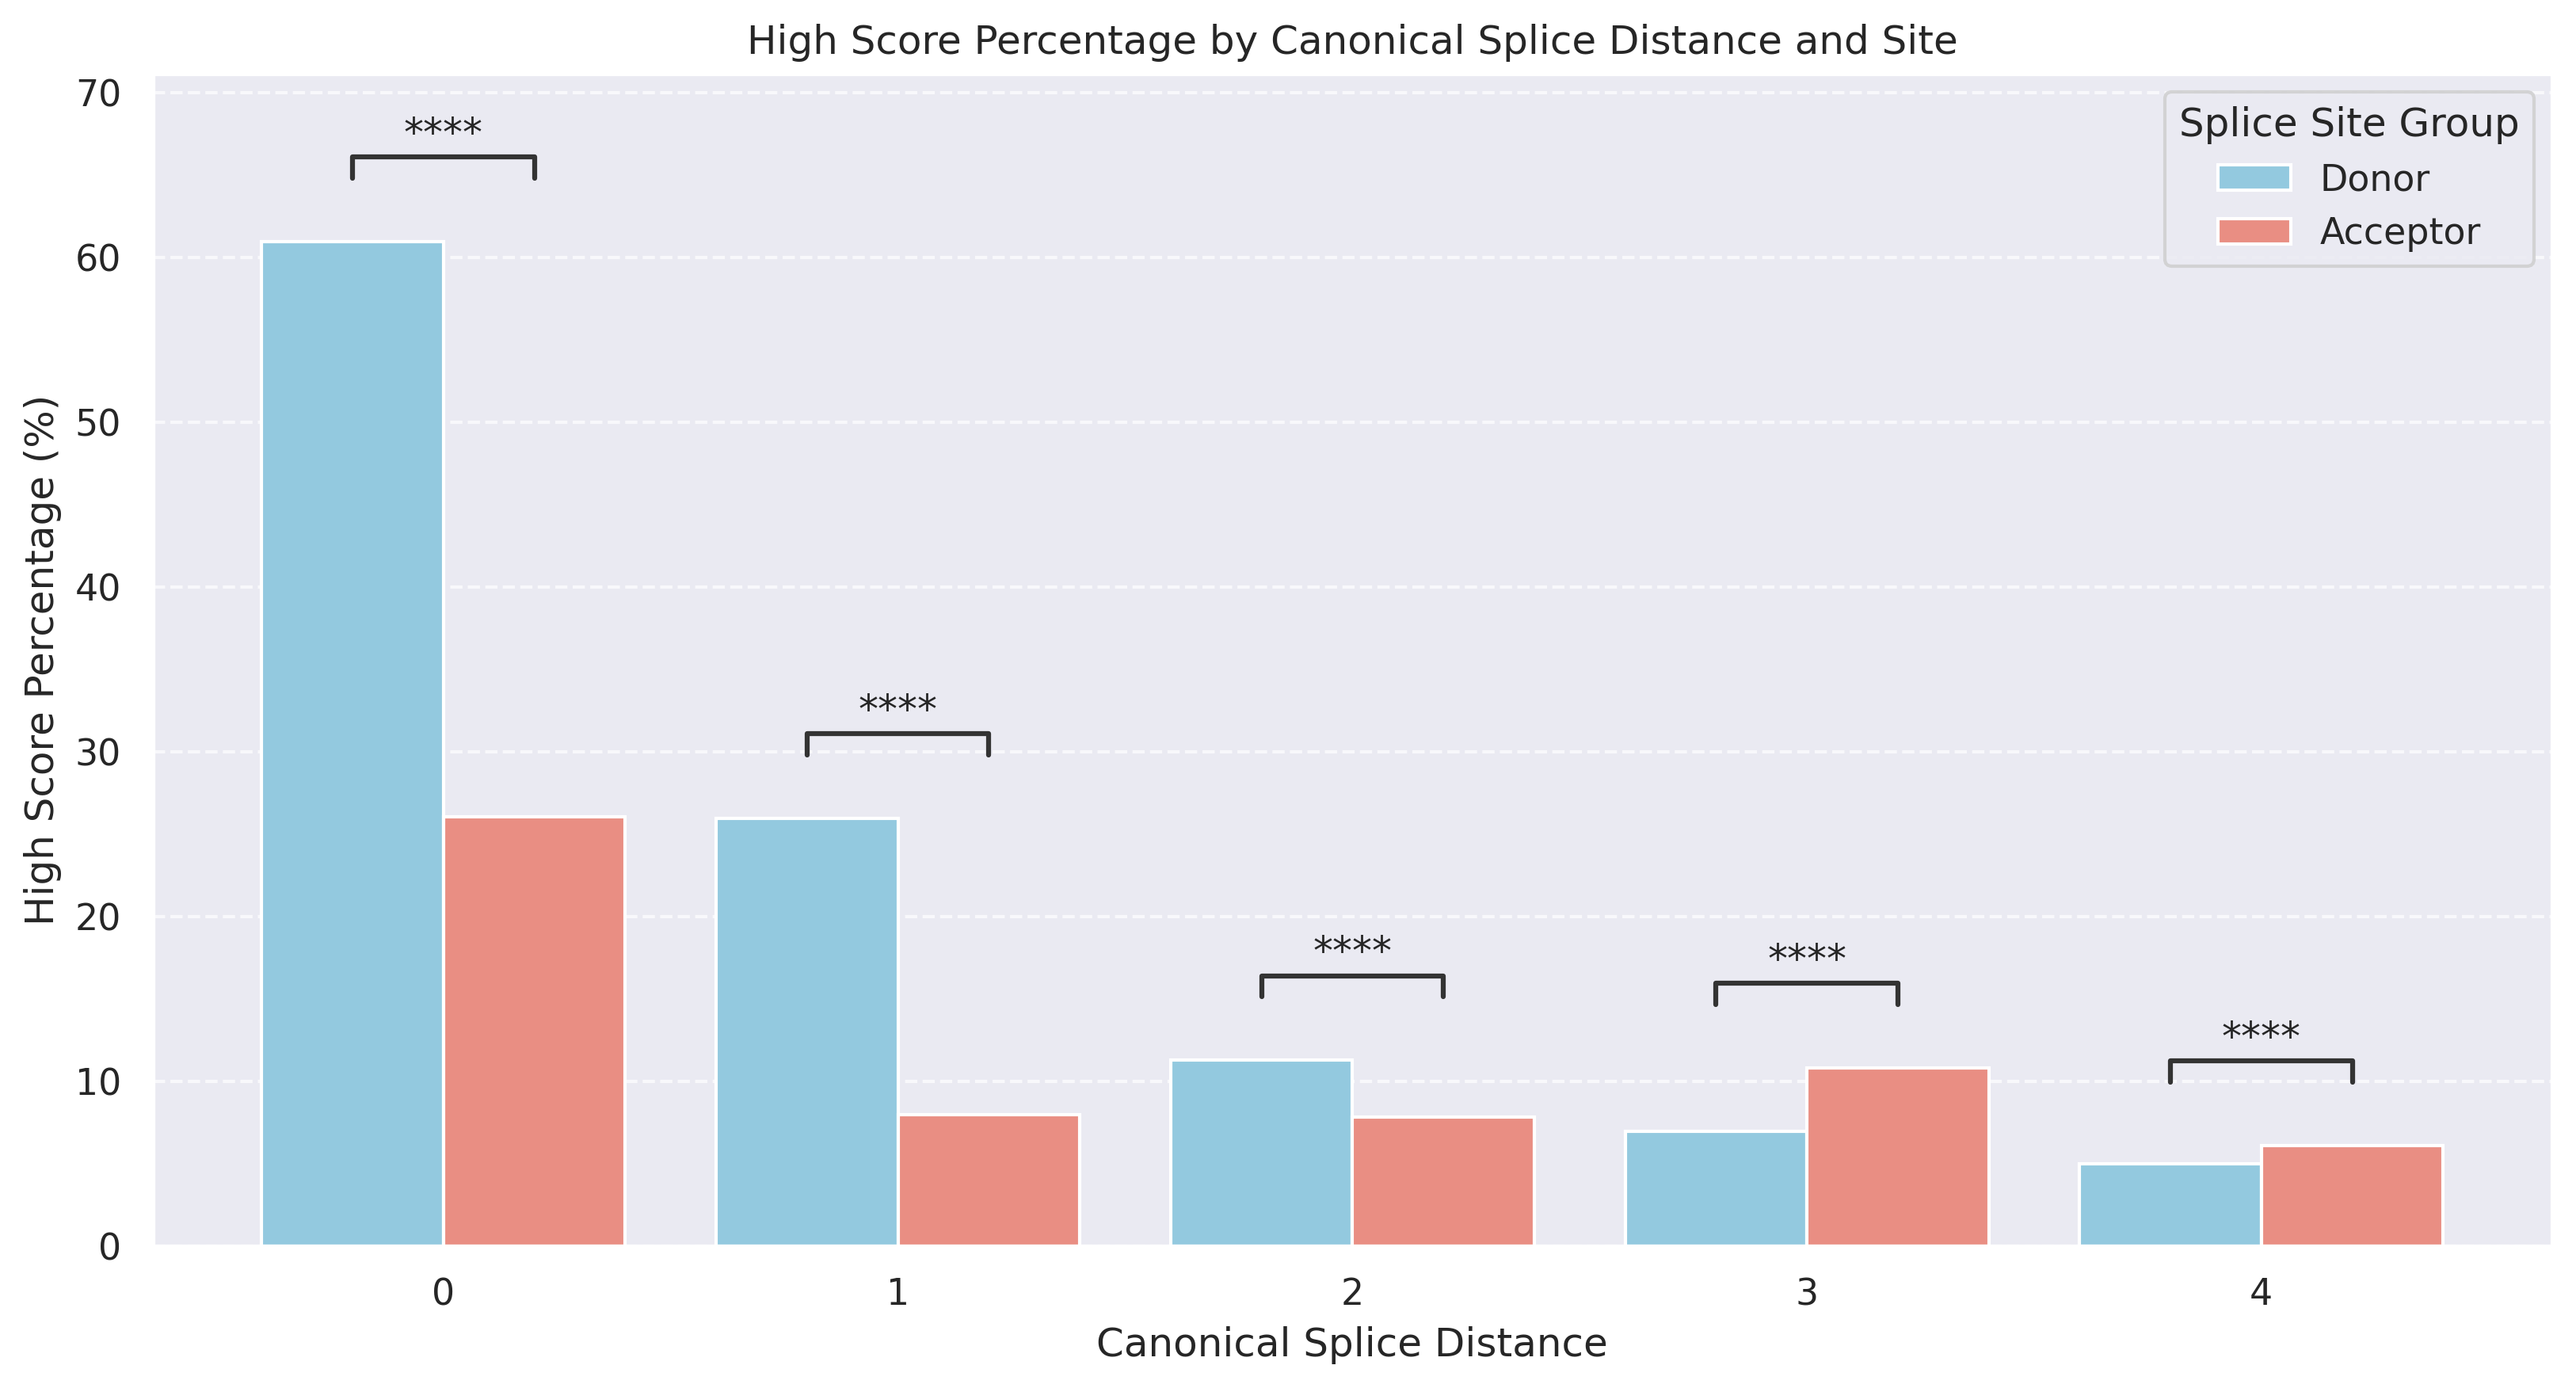

In [89]:
sns.set(rc={"figure.figsize": (11, 6)})
ax = sns.barplot(
    data=sites[sites['Variant_Canonical_Splice_Distance'] < 5],
    x='Variant_Canonical_Splice_Distance',
    y='High_Score_Percentage',
    hue='Site',
    palette={'Donor': 'skyblue', 'Acceptor': 'salmon'}
)

annotator = Annotator(
    ax,
    comp_pairs,
    data=sites[sites['Variant_Canonical_Splice_Distance'] < 5],
    x='Variant_Canonical_Splice_Distance',
    y='High_Score_Percentage',
    hue='Site'
)

annotator.configure(
    test=None,
    test_short_name='Z-Test',
    text_format='star',
    loc='inside'
)

annotator.set_pvalues(p_vals)
annotator.perform_stat_test=False
annotator.annotate()

plt.title('High Score Percentage by Canonical Splice Distance and Site')
plt.xlabel('Canonical Splice Distance')
plt.ylabel('High Score Percentage (%)')
plt.legend(title='Splice Site Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [92]:
distances = site_summary[site_summary['Variant_Canonical_Splice_Distance_donor'] > 4]['Variant_Canonical_Splice_Distance_donor'].unique()

# Initialise list to store comp. pairs + p.vals
comp_pairs = []
p_vals = []

# Perform tests
for d in distances:
    row = site_summary[site_summary['Variant_Canonical_Splice_Distance_donor'] == d].iloc[0]
    # Get the counts for the two groups
    k_donor = row['high_score_variants_donor']
    n_donor = row['total_variants_donor']
    k_acceptor = row['high_score_variants_acceptor']
    n_acceptor = row['total_variants_acceptor']

    # --- Perform the Z-test for two independent proportions ---
    # counts = [k1, k2] (number of successes)
    # nobs = [n1, n2] (number of observations/trials)
    counts = np.array([k_donor, k_acceptor])
    nobs = np.array([n_donor, n_acceptor])

    z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative='two-sided')

    comp_pairs.append(((d, 'Donor'), (d, 'Acceptor')))
    p_vals.append(p_value)

    print(f'Distance {d}: Z-statistic = {z_stat:.4f}, p-value = {p_value:.6f}')

Distance 5: Z-statistic = -9.7636, p-value = 0.000000
Distance 6: Z-statistic = -8.8030, p-value = 0.000000
Distance 7: Z-statistic = -9.4485, p-value = 0.000000
Distance 8: Z-statistic = -4.2271, p-value = 0.000024
Distance 9: Z-statistic = -1.6415, p-value = 0.100691
Distance 10: Z-statistic = 4.0612, p-value = 0.000049
Distance 11: Z-statistic = 1.8984, p-value = 0.057637
Distance 12: Z-statistic = 2.0093, p-value = 0.044509
Distance 13: Z-statistic = 1.5811, p-value = 0.113864
Distance 14: Z-statistic = 2.2602, p-value = 0.023808
Distance 15: Z-statistic = 0.1920, p-value = 0.847752
Distance 16: Z-statistic = 0.5358, p-value = 0.592109
Distance 17: Z-statistic = -2.2440, p-value = 0.024834
Distance 18: Z-statistic = -0.8892, p-value = 0.373895
Distance 19: Z-statistic = -0.2827, p-value = 0.777373
Distance 20: Z-statistic = -1.8742, p-value = 0.060900
Distance 21: Z-statistic = -2.7316, p-value = 0.006302
Distance 22: Z-statistic = -1.5577, p-value = 0.119304
Distance 23: Z-statist

ValueError: `pvalues` should be of the same length as `pairs`.

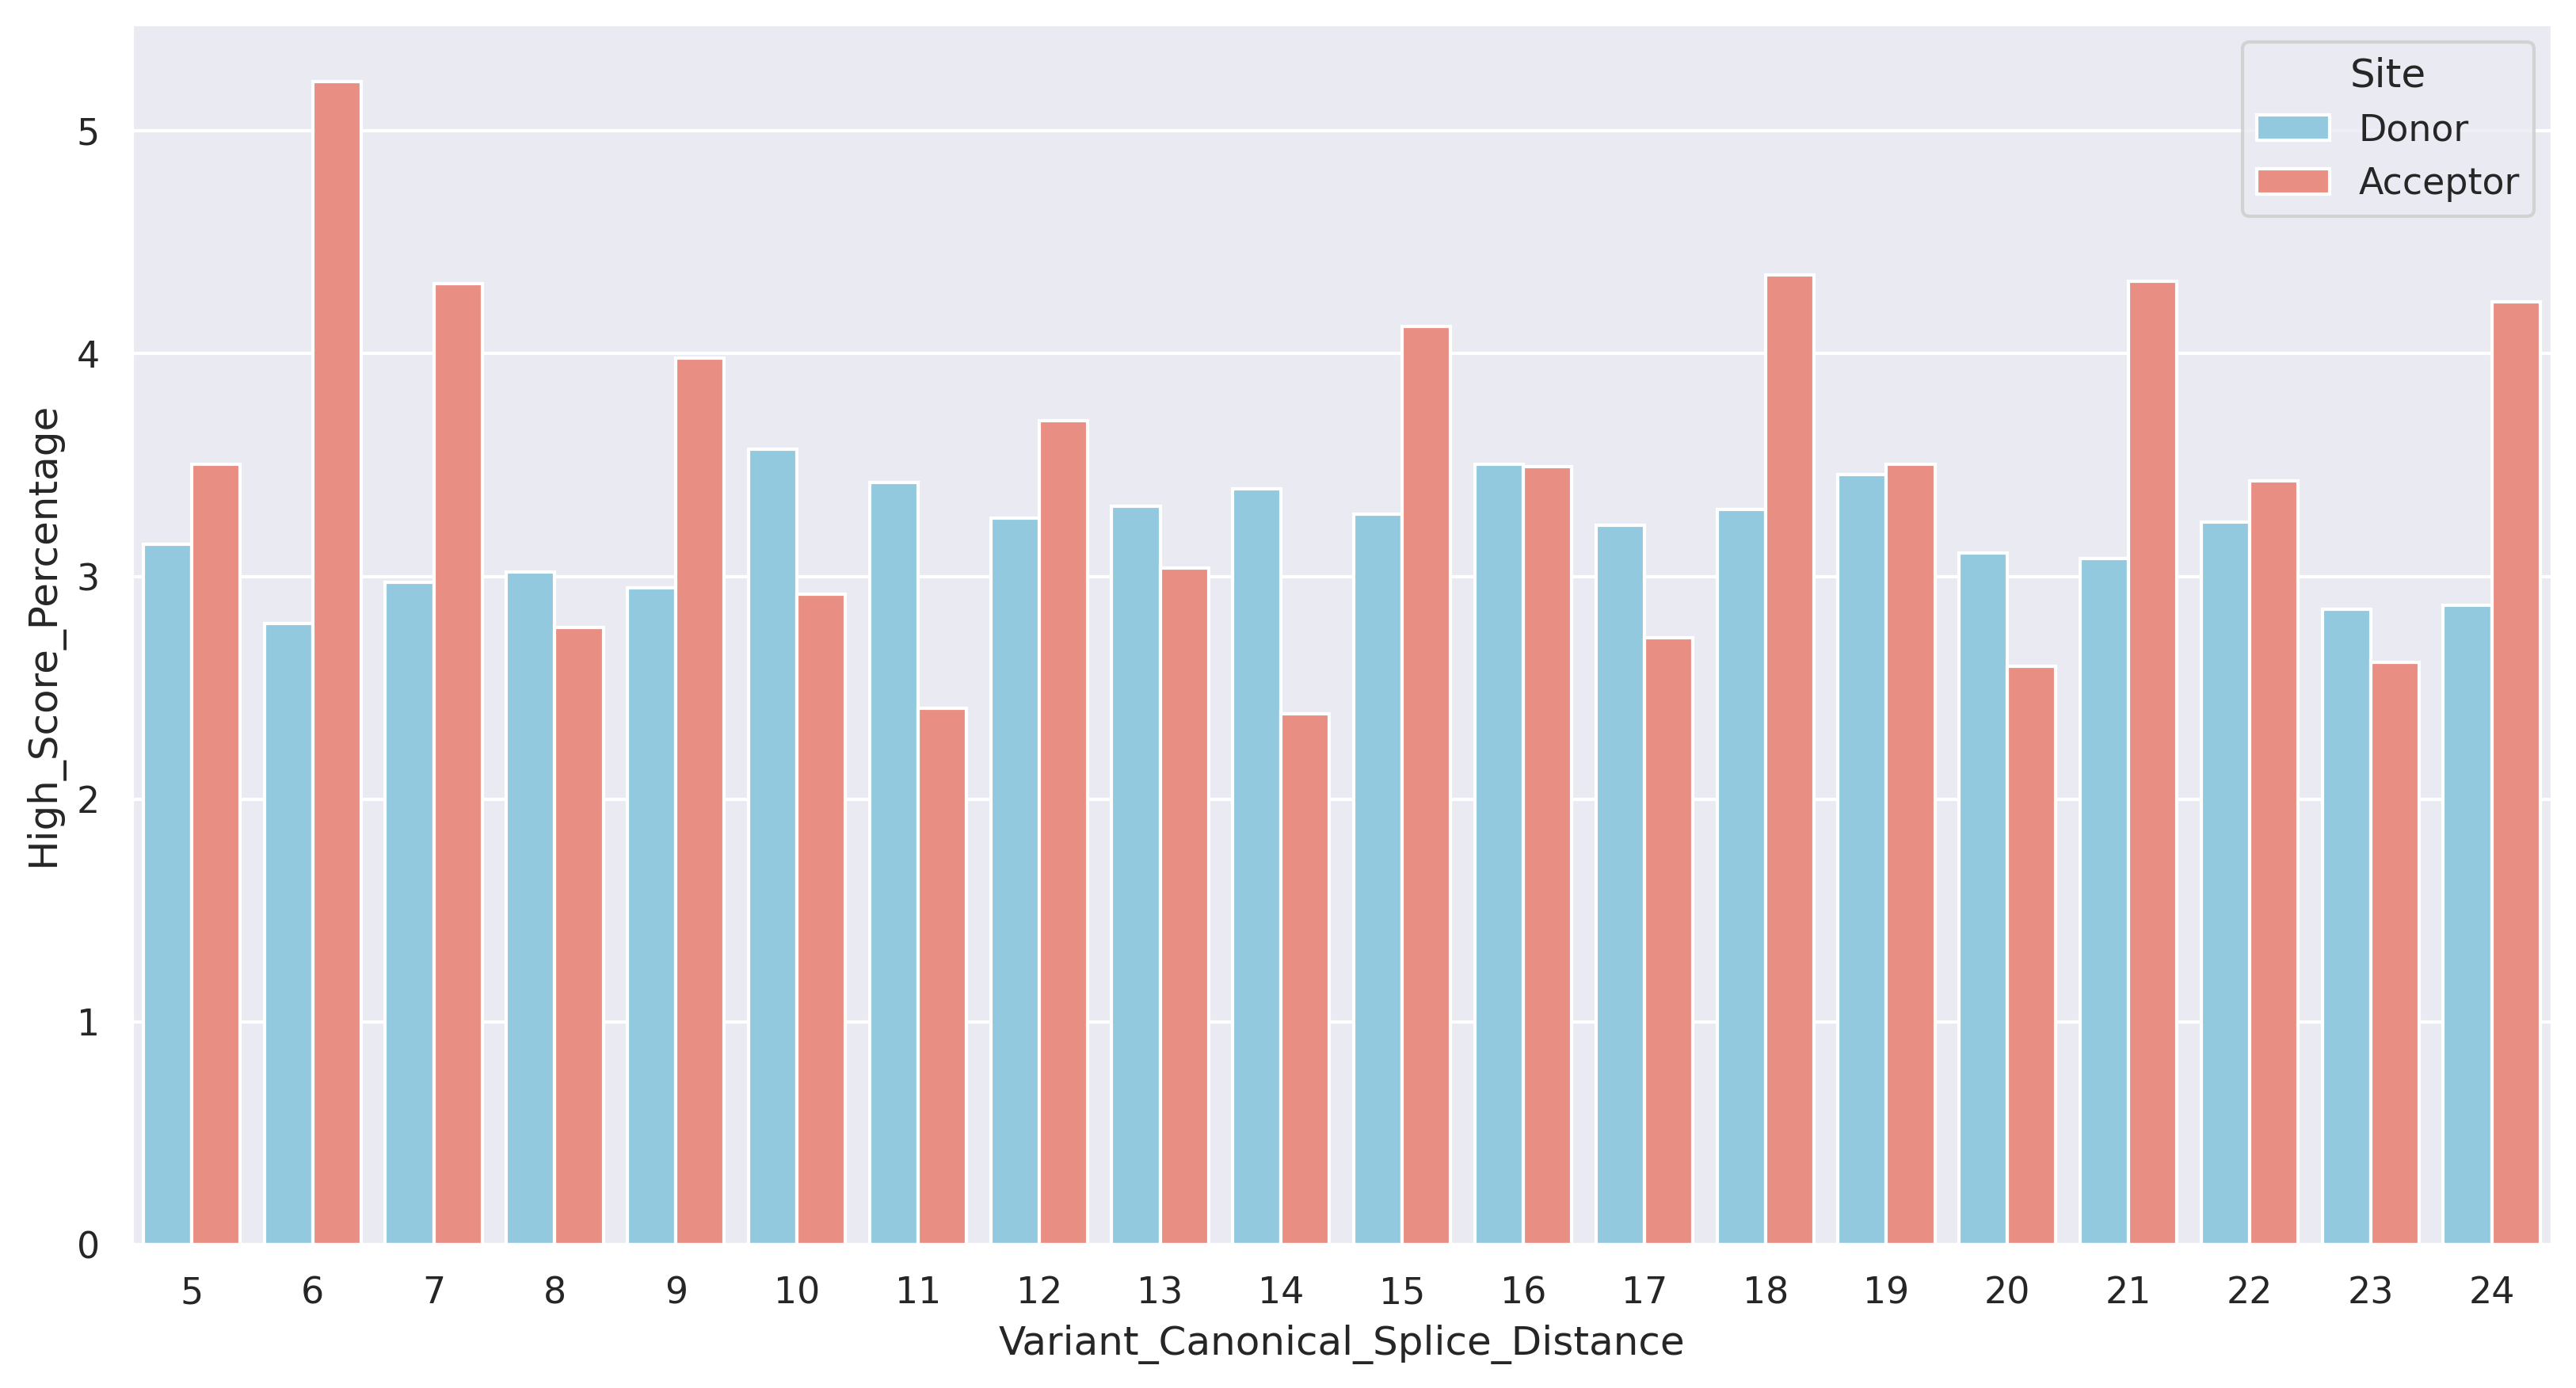

In [93]:
sns.set(rc={"figure.figsize": (11, 6)})
sns.barplot(
    data=sites[sites['Variant_Canonical_Splice_Distance'] > 4],
    x='Variant_Canonical_Splice_Distance',
    y='High_Score_Percentage',
    hue='Site',
    palette={'Donor': 'skyblue', 'Acceptor': 'salmon'}
)
annotator.reset_configuration()
annotator.new_plot(
    ax,
    comp_pairs,
    data=sites[sites['Variant_Canonical_Splice_Distance'] > 4],
    x='Variant_Canonical_Splice_Distance',
    y='High_Score_Percentage',
    hue='Site'
)

annotator.configure(
    test=None,
    test_short_name='Z-Test',
    text_format='star',
    loc='inside'
)

annotator.set_pvalues(p_vals)
annotator.perform_stat_test=False
annotator.annotate()

plt.title('High Score Percentage by Canonical Splice Distance and Site')
plt.xlabel('Canonical Splice Distance')
plt.ylabel('High Score Percentage (%)')
plt.legend(title='Splice Site Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Figure 2

## A) UKB Olink Plot

In [94]:
olink_data = pd.read_csv('/slade/home/mr935/data/biobank_data/olink_files/final_olink_data.csv', index_col=False)

In [100]:
custom_palette = {
    'p.LoF': '#661100', # Dark Red
    'Validated Splice': '#332288', # Indigo
    'p.Splice Missense': '#CC6677',   # Rose
    'p.Splice Synonymous': '#117733', # Green
    'p.Missense Damaging': '#AA4499', # Purple
    'Missense Control': '#888888', # Grey
    'Synonymous Control': '#44AA99' # Teal
}

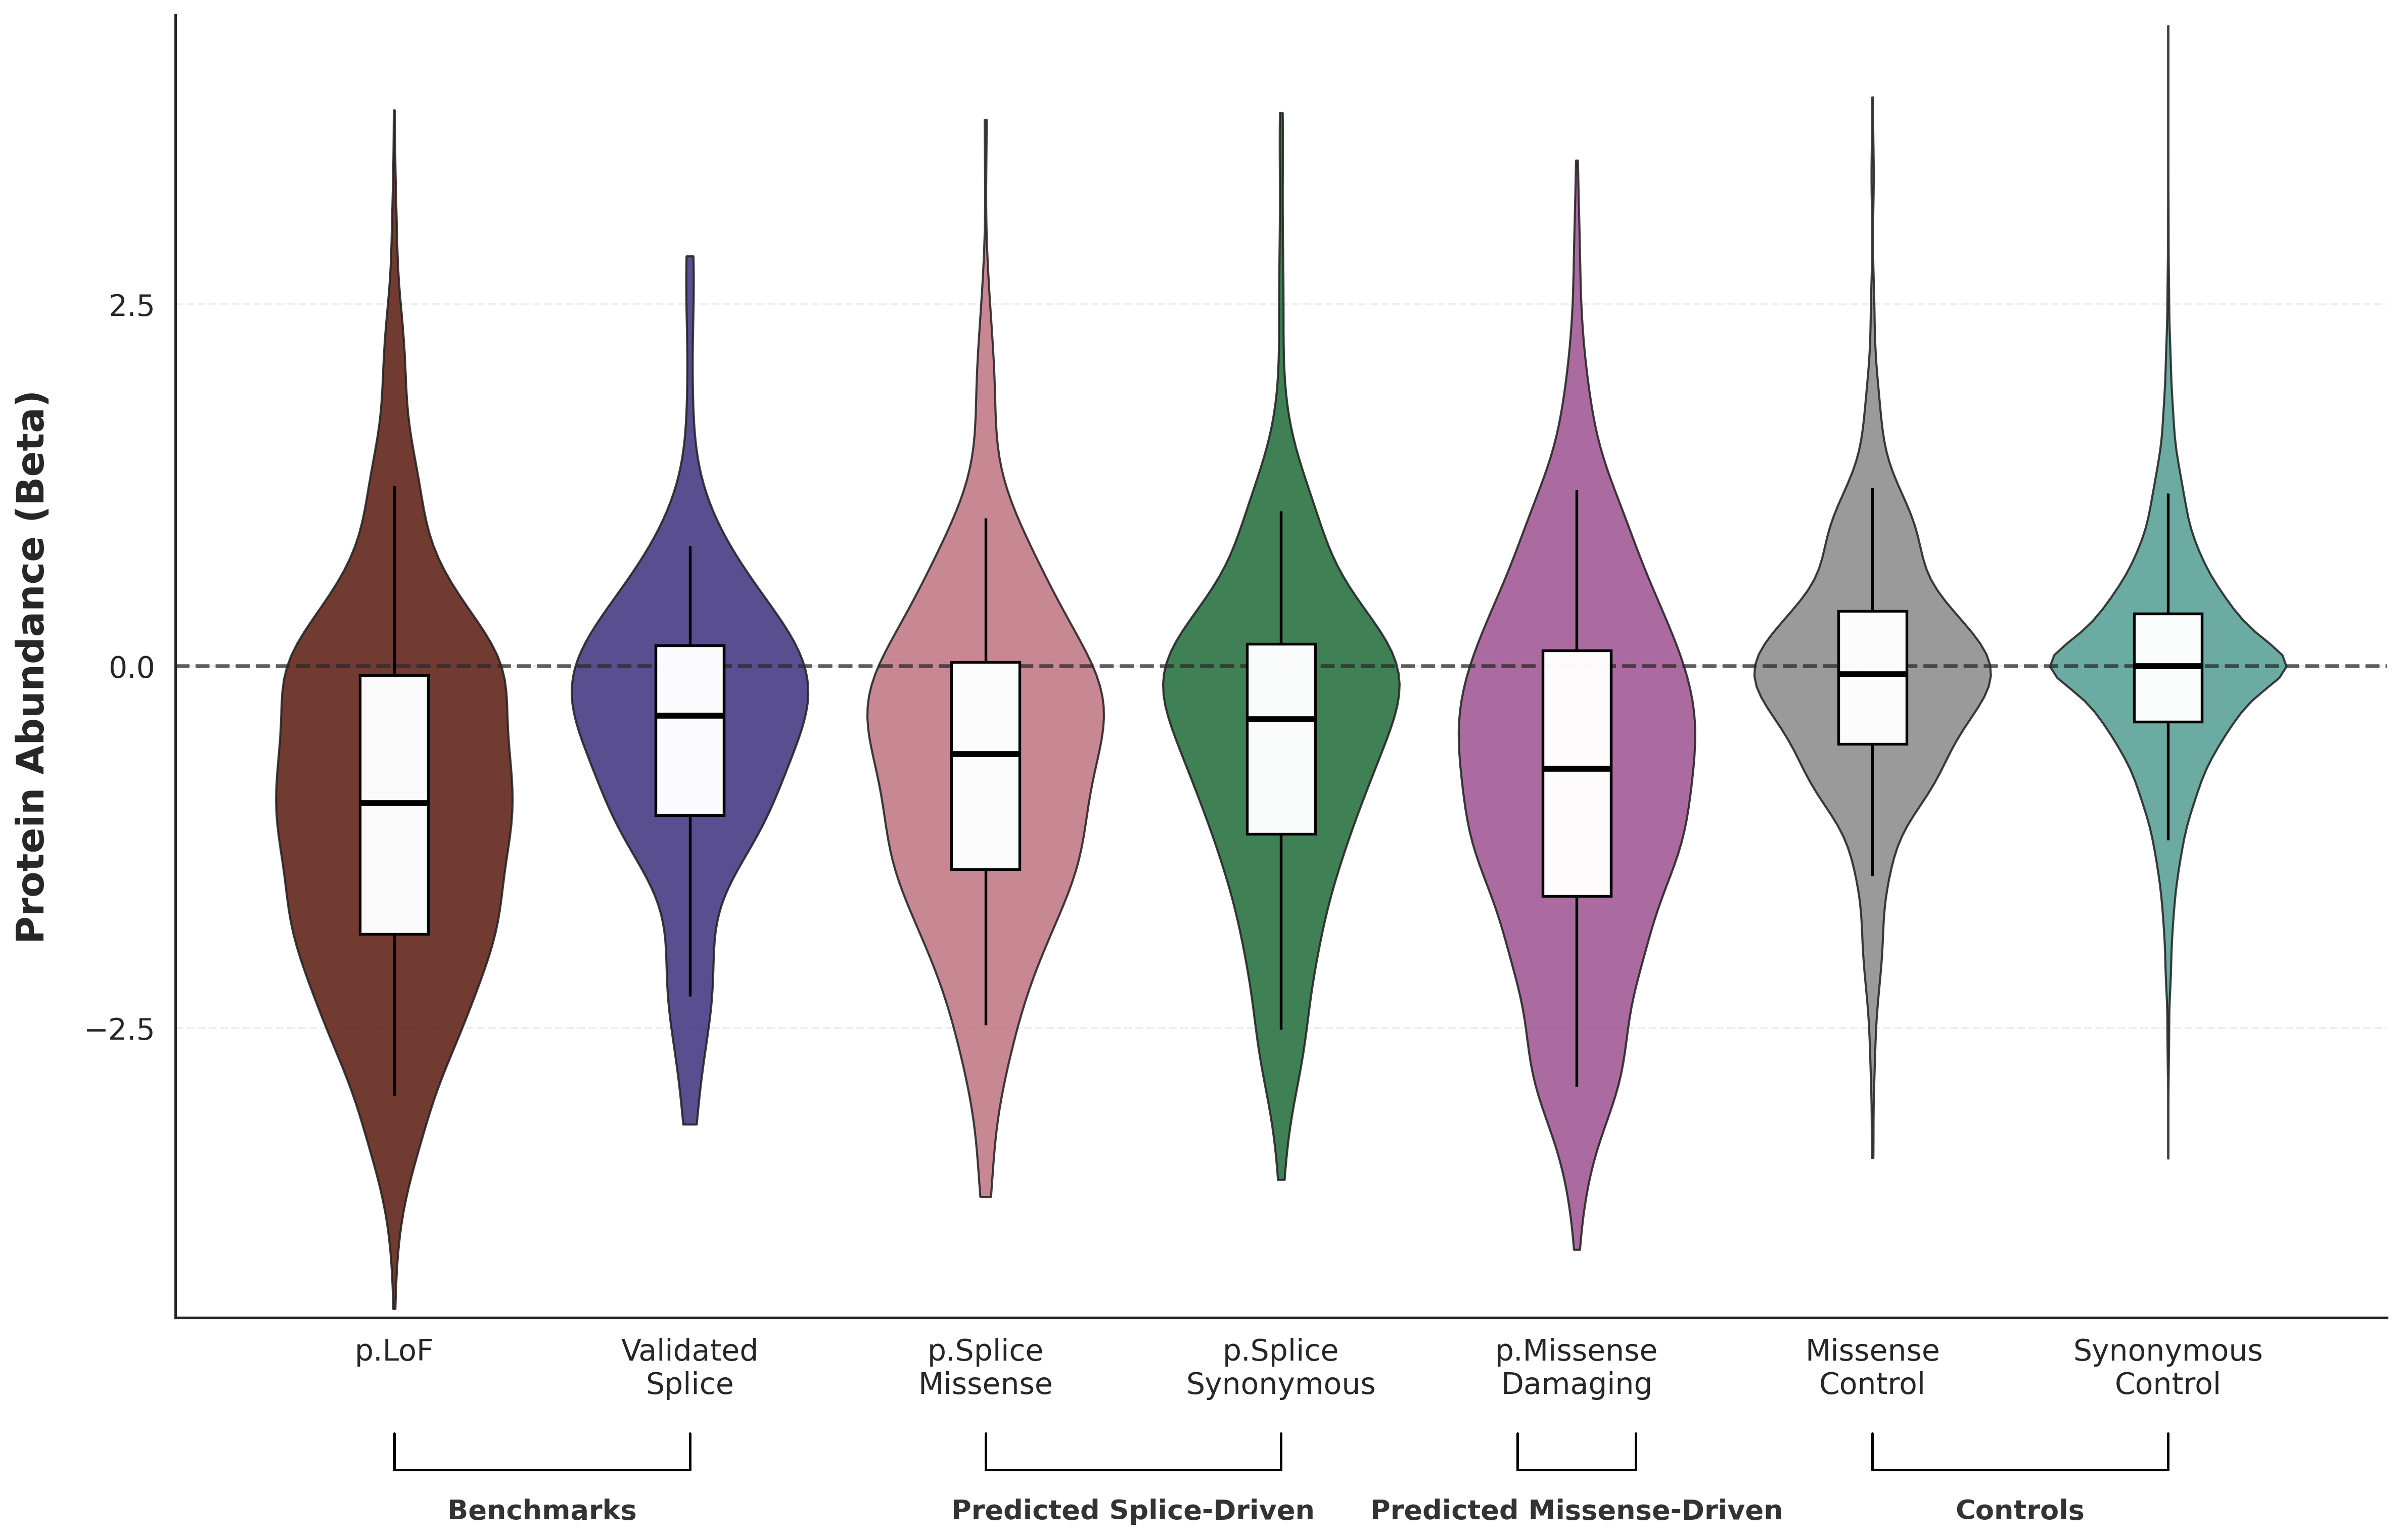

In [101]:
# Setup
mask_order = [
    'p.LoF', 'Validated Splice', 'p.Splice Missense',
    'p.Splice Synonymous', 'p.Missense Damaging',
    'Missense Control', 'Synonymous Control'
]

wrapped_labels = [textwrap.fill(label, width=12) for label in mask_order]

sns.set_style('white') 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots(figsize=(16, 10))

# Background grid
ax.yaxis.grid(True, linestyle='--', which='major', color='#E0E0E0', alpha=0.5, zorder=0)

# Violin Plot
sns.violinplot(
    data=olink_data,
    x='Mask',
    y='Beta',
    order=mask_order,
    hue='Mask',
    palette=custom_palette,
    legend=False,
    inner=None,             
    cut=0,                  # No tail extrapolation
    density_norm='width',
    linewidth=1.0,
    alpha=0.85,            
    ax=ax,
    zorder=1
)

# Neutrality Baseline
ax.axhline(
    0, 
    color='#2B2B2B', 
    linestyle='--', 
    alpha=0.75, 
    linewidth=1.8, 
    zorder=1.5               # Visible over violins, under boxplots
)

# Mini Boxplot Overlay
sns.boxplot(
    data=olink_data,
    x='Mask',
    y='Beta',
    order=mask_order,
    width=0.23,             
    color='white',
    fliersize=0,   
    showcaps=False,
    whis=(5, 95), 
    ax=ax,
    zorder=2,
    boxprops=dict(facecolor='white', edgecolor='black', alpha=0.98, linewidth=1.3),
    whiskerprops=dict(color='black', linewidth=1.3),
    medianprops=dict(color='black', linewidth=2.8)
)

# Grouping Brackets
groups = [
    (0, 1, 'Benchmarks'),
    (2, 3, 'Predicted Splice-Driven'),
    (3.8, 4.2, 'Predicted Missense-Driven'),
    (5, 6, 'Controls')
]

bracket_y = -5.55
bracket_height = 0.25

for start, end, label in groups:
    ax.plot([start, end], [bracket_y, bracket_y], color='black', lw=1.2, clip_on=False)
    ax.plot([start, start], [bracket_y, bracket_y + bracket_height], color='black', lw=1.2, clip_on=False)
    ax.plot([end, end], [bracket_y, bracket_y + bracket_height], color='black', lw=1.2, clip_on=False)
    ax.text((start + end) / 2, bracket_y - 0.2, label, ha='center', va='top', fontsize=13, fontweight='bold', color='#333333')

# Formatting
ax.set_ylim(-4.5, 4.5)
ax.set_yticks([-2.5, 0, 2.5])

ax.set_xlabel('', fontsize=18)
ax.set_ylabel('Protein Abundance (Beta)', fontsize=18, fontweight='bold', labelpad=15)

plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=0, fontsize=14)
ax.tick_params(axis='y', which='major', labelsize=14, direction='out', length=6, width=1.2)

sns.despine(left=False, bottom=False)
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

#plt.savefig('/slade/home/mr935/figures/Spliceogenic_Missense/Olink_Plot.pdf', format='pdf', bbox_inches='tight', transparent=True, dpi=600)
plt.show()

## B) Olink Heatmap

In [ ]:
# Extract data into a dictionary for speed
mask_data = {m: olink_data[olink_data['Mask'] == m]['Beta'].values for m in mask_order}

#  Observed Difference to test against
def median_diff(x, y):
    return np.median(x) - np.median(y)

# Pairwise Permutations
results = []
for m1, m2 in combinations(mask_order, 2):
    res = permutation_test(
        (mask_data[m1], mask_data[m2]), 
        median_diff,
        permutation_type='independent',
        n_resamples=50000,
        alternative='two-sided'
    )
    
    results.append({
        'Mask_A': m1, 'Mask_B': m2,
        'Diff': res.statistic,
        'p_val': res.pvalue
    })

results_df = pd.DataFrame(results)

# FDR Correction
results_df['q_val'] = multipletests(results_df['p_val'], method='fdr_bh')[1]

# Build Signed Significance Matrix
# -log10(Q) * sign(Diff)
results_df['sig_score'] = -np.log10(results_df['q_val']) * np.sign(results_df['Diff'])

# Pivot into square matrix for heatmap
matrix = results_df.pivot(index='Mask_A', columns='Mask_B', values='sig_score')
matrix = matrix.combine_first(-matrix.T).reindex(index=mask_order, columns=mask_order)


In [111]:
# Beta Matrix (for reference)
beta_matrix = results_df.pivot(index='Mask_A', columns='Mask_B', values='Diff')
beta_matrix = beta_matrix.combine_first(-beta_matrix.T).reindex(index=mask_order, columns=mask_order)

# Q-Value Matrix (used to generate the '***' strings)
q_matrix = results_df.pivot(index='Mask_A', columns='Mask_B', values='q_val')
q_matrix = q_matrix.combine_first(q_matrix.T).reindex(index=mask_order, columns=mask_order)

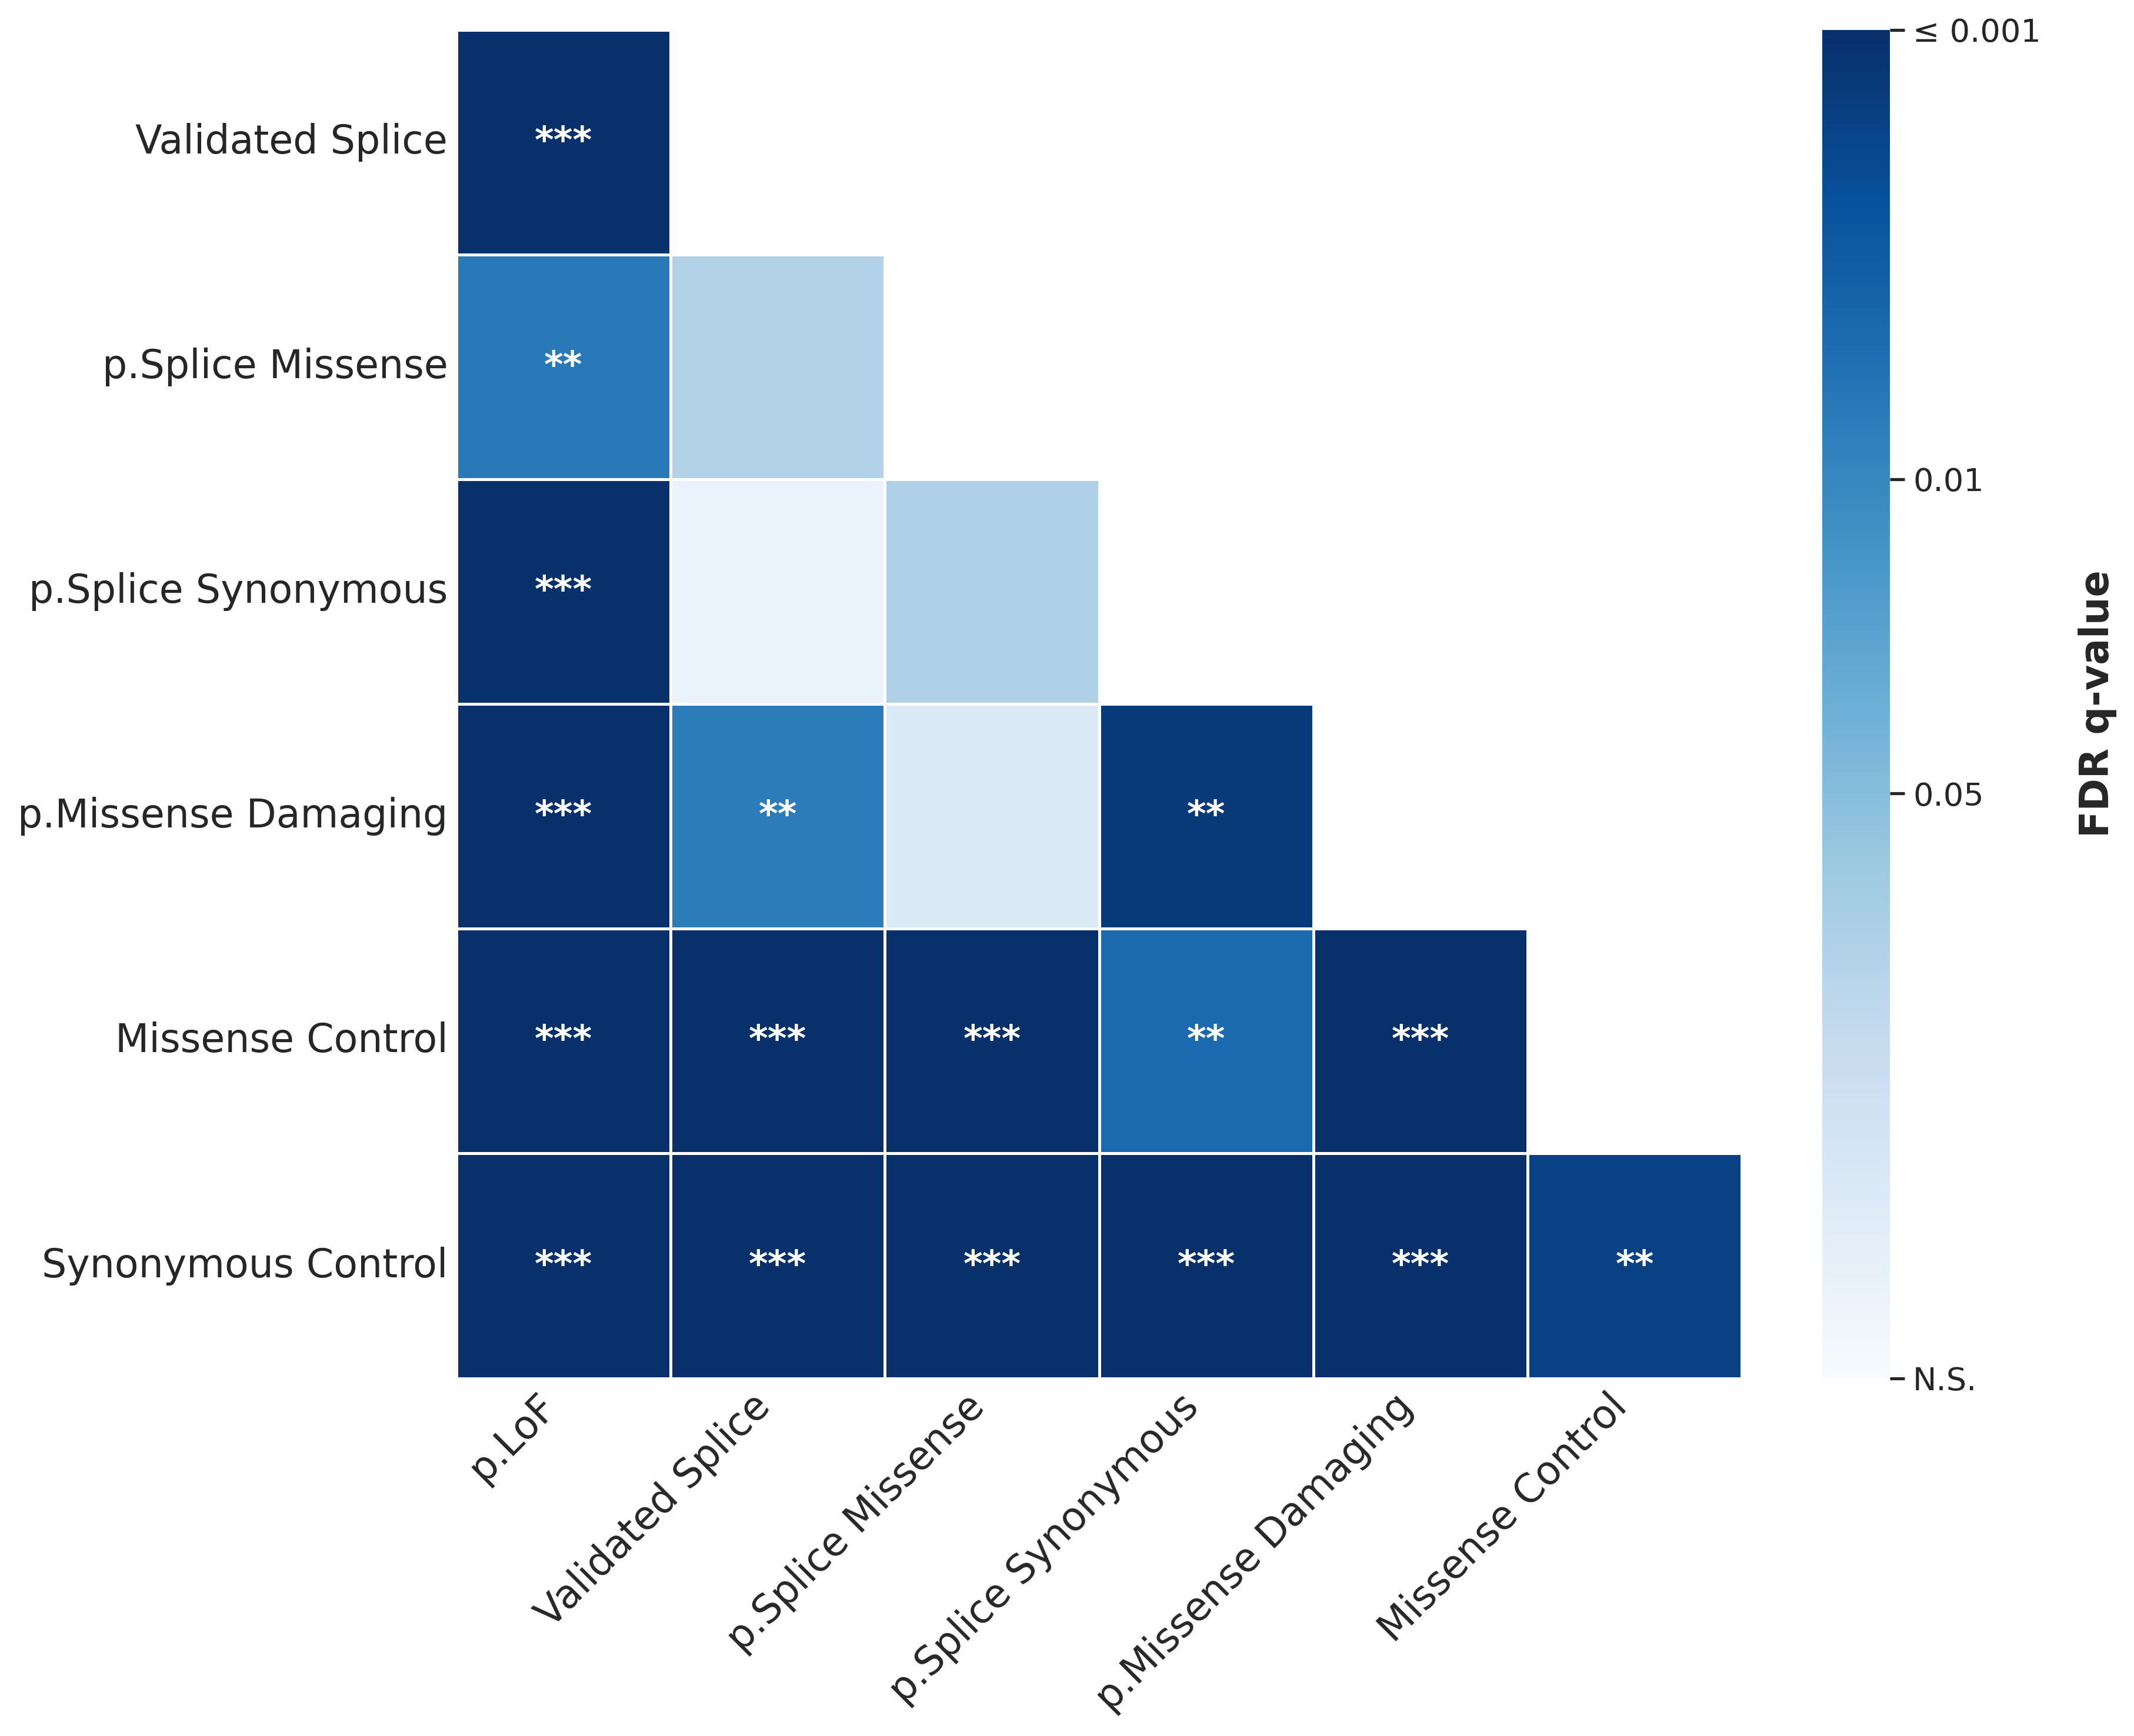

In [113]:
# Setup
sns.set_style("white")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 300


def annotate_sig_stars(val):
    if pd.isna(val) or val >= 0.05:
        return ""
    if val < 0.001:
        return "***"
    if val < 0.01:
        return "**"
    return "*"


# Matrices focusing on significance magnitude (-log10 q-value)
q_annot_matrix = q_matrix.reindex(
    index=mask_order, columns=mask_order
).map(annotate_sig_stars)

# Significance matrix
sig_matrix = -np.log10(q_matrix.reindex(index=mask_order, columns=mask_order))

# Cap visual scale at -log10(q) = 3 (q <= 0.001) for clean color saturation
plot_matrix = sig_matrix.clip(upper=3)

# Lower-triangle mask
triangle_mask = np.triu(np.ones_like(plot_matrix, dtype=bool), k=0)
masked_annot = q_annot_matrix.where(~triangle_mask, "")

plot_matrix_sliced = plot_matrix.iloc[1:, :-1]
masked_annot_sliced = masked_annot.iloc[1:, :-1]
triangle_mask_sliced = triangle_mask[1:, :-1]

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    plot_matrix_sliced,
    annot=masked_annot_sliced,
    fmt="s",
    cmap="Blues",  # Sequential palette representing magnitude of significance
    vmin=0,
    vmax=3,  # 0 = not significant, 1.3 ≈ q=0.05, >=3 = q<=0.001
    linewidths=1.2,
    linecolor="white",
    cbar=True,
    mask=triangle_mask_sliced,
    ax=ax,
    annot_kws={"size": 15, "fontweight": "bold"},
)

# Formatting
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.tick_bottom()
ax.xaxis.set_label_position("bottom")
ax.tick_params(axis="both", which="both", length=0)

plt.xticks(rotation=45, ha="right", fontsize=16)
plt.yticks(rotation=0, fontsize=16)

# Colourbar for Significance 
cbar = ax.collections[0].colorbar
cbar.set_label("FDR q-value", fontsize=16, fontweight="bold", labelpad=15)

cbar.set_ticks([0, 1.301, 2.0, 3.0])
cbar.set_ticklabels(["N.S.", "0.05", "0.01", "≤ 0.001"], fontsize=13)
cbar.outline.set_visible(False)

# Save figure as PDF
# plt.savefig(
#     "/slade/home/mr935/figures/Spliceogenic_Missense/Olink_Significance_Heatmap.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     transparent=True,
#     dpi=600,
# )

plt.tight_layout()
plt.show()

## C) FoldX Plot

In [115]:
protvar_checks = pd.read_csv('/slade/home/mr935/data/biobank_data/olink_spliceogenic_and_damaging_missense_protvar.tsv', sep='\t', index_col=False)
protvar_checks.head()

,Gene,Variant,Alt_Freq,Beta,log10,Mask,variantID,UniProt ID(supplied by UniProt),Amino_acids,Protein_position,wild_type,mutated_type,uniprot_accession,uniprot_position,foldx_ddg,Destabilising
0,VWA1,1:1436969:T:C,0.000011,-1.818560,1.320730,Missense Damaging,chr1-1436969-T-C,Q6PCB0,L/P,39,L,P,Q6PCB0,39.0,7.98978,True
1,PARK7,1:7984945:C:T,0.000011,-0.432754,0.184176,Missense Damaging,chr1-7984945-C-T,Q99497,T/I,154,T,I,Q99497,154.0,4.27077,True
2,PARK7,1:7984947:A:T,0.000011,-0.426930,0.181349,Missense Damaging,chr1-7984947-A-T,Q99497,S/C,155,S,C,Q99497,155.0,2.44712,True
3,NMNAT1,1:9972117:G:A,0.000022,-0.485755,0.335728,Missense Damaging,chr1-9972117-G-A,Q9HAN9,G/D,15,G,D,Q9HAN9,15.0,0.83340,False
4,NMNAT1,1:9975655:T:A,0.000011,-0.199654,0.080627,Missense Damaging,chr1-9975655-T-A,Q9HAN9,L/H,60,L,H,Q9HAN9,60.0,4.61978,True


In [119]:
stable_vars = protvar_checks[protvar_checks['Destabilising'] == False].copy().reset_index(drop=True)
unstable_vars = protvar_checks[protvar_checks['Destabilising'] == True].copy().reset_index(drop=True)

In [120]:
stable_vars['Mask'].value_counts()

Mask
p.Missense Damaging    372
p.Splice Missense      264
Name: count, dtype: int64

In [121]:
stable_vars[stable_vars['Mask'] == 'p.Splice Missense']['Beta'].median()

np.float64(-0.669497)

In [122]:
stable_vars[stable_vars['Mask'] == 'p.Protein Damaging']['Beta'].median()

nan

In [123]:
# Permutation Test
# Data Prep
splice_beta = stable_vars[stable_vars['Mask'] == 'p.Splice Missense']['Beta'].values
missense_beta = stable_vars[stable_vars['Mask'] == 'p.Missense Damaging']['Beta'].values

# Observed Difference to test against
def median_diff(x, y):
    return np.median(x) - np.median(y)

# Run test
res = permutation_test(
    (splice_beta, missense_beta), 
    median_diff, 
    permutation_type='independent', 
    vectorized=False, 
    n_resamples=500000, 
    alternative='two-sided'
)

print(f"Observed Difference: {res.statistic}")
print(f"P-value: {res.pvalue}")

Observed Difference: -0.31684100000000004
P-value: 0.00731998536002928


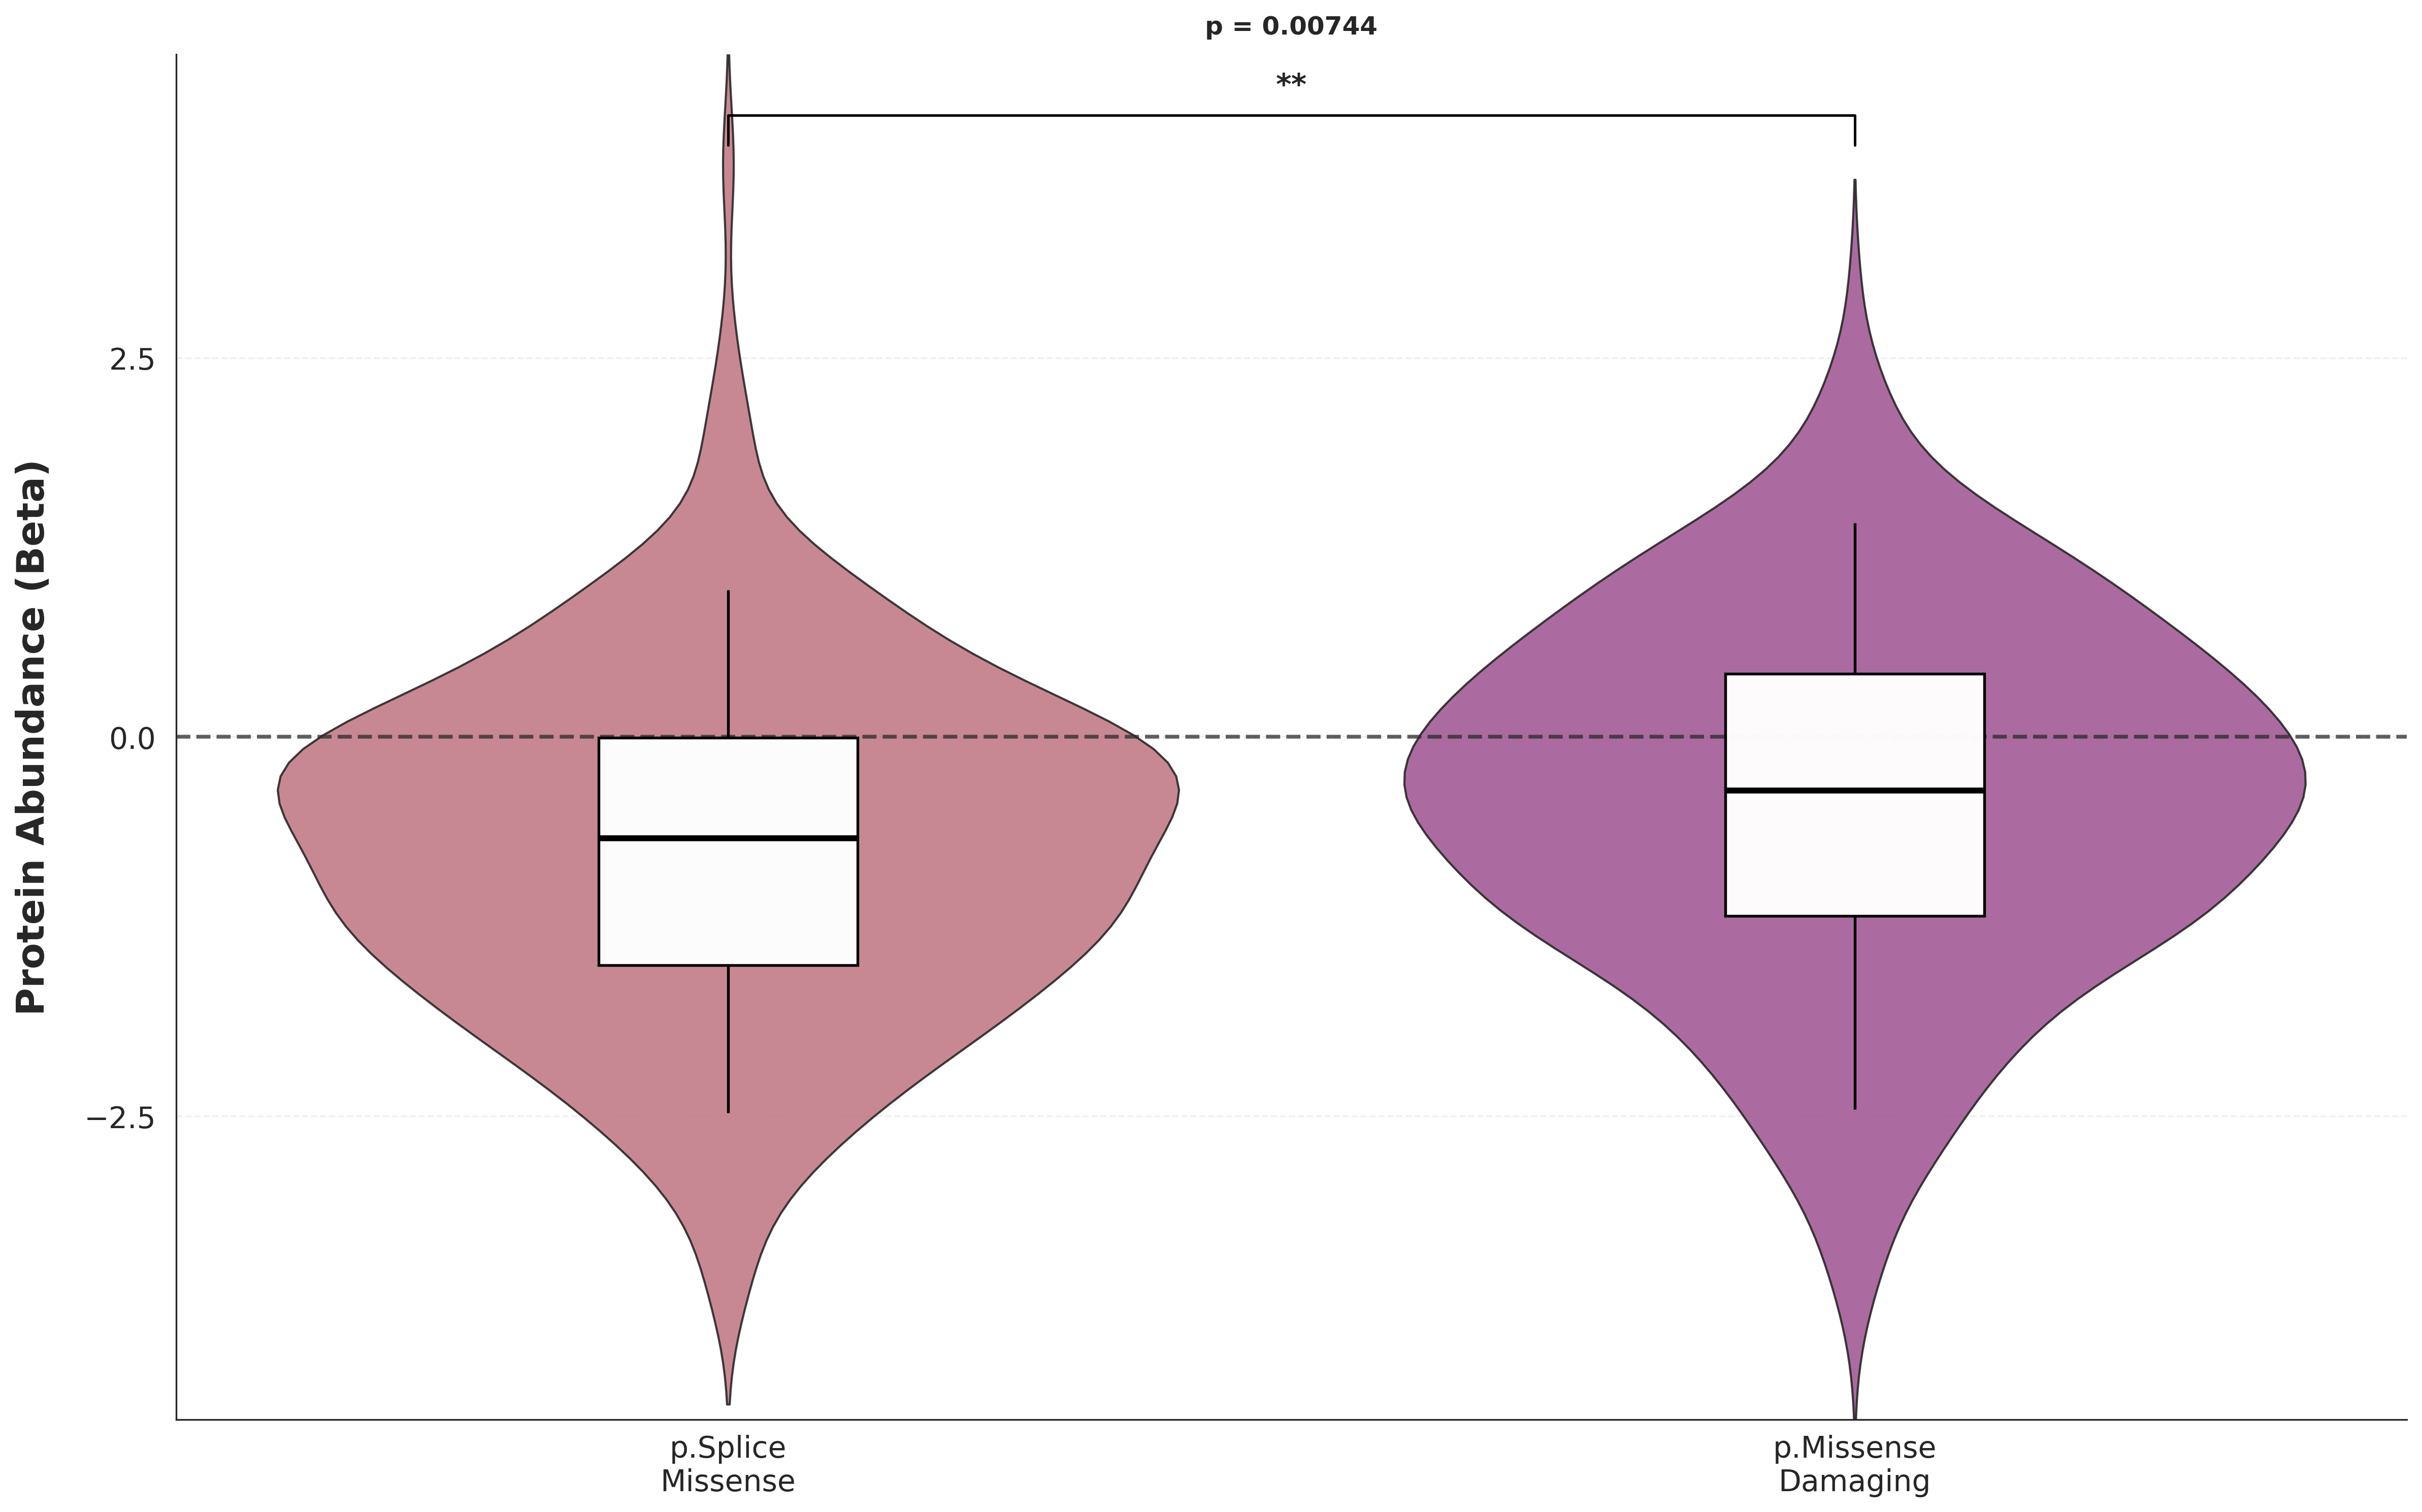

In [13]:
# Setup
mask_order = [
    'p.Splice Missense', 'p.Missense Damaging'
]

wrapped_labels = [textwrap.fill(label, width=12) for label in mask_order]

sns.set_style('white') 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 300


fig, ax = plt.subplots(figsize=(16, 10))

# Background grid
ax.yaxis.grid(True, linestyle='--', which='major', color='#E0E0E0', alpha=0.5, zorder=0)

# Violin Plot
sns.violinplot(
    data=stable_vars,
    x='Mask',
    y='Beta',
    order=mask_order,
    hue='Mask',
    palette=custom_palette,
    legend=False,
    inner=None,                          
    density_norm='width',
    linewidth=1.0,
    alpha=0.85,             
    ax=ax,
    zorder=1
)

# Neutrality Baseline
ax.axhline(
    0, 
    color='#2B2B2B', 
    linestyle='--', 
    alpha=0.75, 
    linewidth=1.8, 
    zorder=1.5              
)

# Mini Boxplot Overlay
sns.boxplot(
    data=stable_vars,
    x='Mask',
    y='Beta',
    order=mask_order,
    width=0.23,            
    color='white',
    fliersize=0,   
    showcaps=False,
    whis=(5, 95), 
    ax=ax,
    zorder=2,
    boxprops=dict(facecolor='white', edgecolor='black', alpha=0.98, linewidth=1.3),
    whiskerprops=dict(color='black', linewidth=1.3),
    medianprops=dict(color='black', linewidth=2.8)
)

# Significance Annotation
y_max = stable_vars['Beta'].max()
line_y = 4.1 
line_h = 0.2

x1, x2 = 0, 1
ax.plot([x1, x1, x2, x2], [line_y - line_h, line_y, line_y, line_y - line_h], lw=1.2, c='k')

# Significance Text
ax.text((x1 + x2) * .5, line_y + 0.1, "**", ha='center', va='bottom', 
        fontsize=14, fontweight='bold')
ax.text((x1 + x2) * .5, line_y + 0.5, "p = 0.00744", ha='center', va='bottom', 
        fontsize=12, fontweight='bold')

# Formatting
ax.set_ylim(-4.5, 4.5)
ax.set_yticks([-2.5, 0, 2.5])

ax.set_xlabel('', fontsize=18)
ax.set_ylabel('Protein Abundance (Beta)', fontsize=18, fontweight='bold', labelpad=15)

plt.xticks(ticks=range(len(wrapped_labels)), labels=wrapped_labels, rotation=0, fontsize=14)
ax.tick_params(axis='y', which='major', labelsize=14, direction='out', length=6, width=1.2)

sns.despine(left=False, bottom=False)
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()

#plt.savefig('/slade/home/mr935/figures/Spliceogenic_Missense/Olink_Plot.pdf', format='pdf', bbox_inches='tight', transparent=True, dpi=600)
plt.show()

## D) & E) - InFrame vs Frameshift with New Site vs Canonical Site

In [124]:
# Load data skipping pre-header comments
# Reannotated olink data using SpliceAIMod found at
# https://github.com/chundruv/SpliceAImod
x = pd.read_csv('/slade/home/mr935/data/final_olink_data_out.tsv.gz', sep='\t', skiprows=31)
y = pd.read_csv('/slade/home/mr935/data/final_olink_data.csv.gz')

# Format Variant string
chrom_clean = x['#CHROM'].astype(str).str.replace('chr', '', regex=False)
x['Variant'] = chrom_clean + ':' + x['POS'].astype(str) + ':' + x['REF'].astype(str) + ':' + x['ALT'].astype(str)

# Inner join on Variant
z = pd.merge(x, y, on='Variant', how='inner')
z = z[z['Beta'].notna()].copy()

In [125]:
# Data Prep
dsm_cols = ['DSM_AG', 'DSM_AL', 'DSM_DG', 'DSM_DL']
for col in dsm_cols:
    z[col] = pd.to_numeric(z[col], errors='coerce')

z['Max_DSM_Score'] = z[dsm_cols].max(axis=1)

In [126]:
# Regex extraction functions
z['Is_Minor'] = z['EVENT_CLASS'].str.contains('_Minor', na=False)
z['Is_PTC'] = z['EVENT_CLASS'].str.contains('_PTC', na=False)
z['Is_NonCoding'] = (z['EVENT_CLASS'] == 'NonCoding') | z['EVENT_CLASS'].str.contains('_NonCoding', na=False)

z['Clean_Class'] = z['EVENT_CLASS'].str.replace('_Minor|_PTC', '', regex=True)

z['FS_Proportion'] = z['Clean_Class'].str.extract(r'(?<=Frameshift\()([0-9.]+)(?=_)')[0].astype(float) * 100
z['FS_AA_Count'] = z['Clean_Class'].str.extract(r'(?<=_)(\d+)(?=aa_)')[0].astype(float)
z['FS_Dist_To_Stop'] = z['Clean_Class'].str.extract(r'(?<=aa_)([0-9]+)(?=\))')[0].astype(float)

z['Clean_Class'] = z['Clean_Class'].str.replace(r'Frameshift\([0-9._a-zA-Z?]+\)', 'Frameshift', regex=True)

z['InFrame_Proportion'] = z['Clean_Class'].str.extract(r'(?<=_)([0-9.]+)(?=\))')[0].astype(float) * 100
z['Clean_Class'] = z['Clean_Class'].str.replace(r'_[0-9.]+', '', regex=True)

In [127]:
# Binning Frameshift
def bin_fs(prop):
    if pd.isna(prop): return "Unknown"
    elif prop <= 20: return "0-20%"
    elif prop <= 40: return "21-40%"
    elif prop <= 60: return "41-60%"
    elif prop <= 80: return "61-80%"
    elif prop <= 100: return "81-100%"
    else: return "Unknown"

z['FS_Binned'] = z['FS_Proportion'].apply(bin_fs)

z['aa_size'] = z['Clean_Class'].str.extract(r'InFrame(?:Insertion|Deletion)\((\d+)aa\)')[0].astype(float)

In [128]:
# Binning InFrame
def bin_if(prop):
    if pd.isna(prop): return "Unknown"
    elif prop <= 1: return "0-1%"
    elif prop <= 5: return "2-5%"
    elif prop <= 10: return "6-10%"
    elif prop > 10: return "11-100%"
    else: return "Unknown"

z['IF_Binned'] = z['InFrame_Proportion'].apply(bin_if)

z['InFrame_Type'] = np.select(
    [z['EVENT_CLASS'].str.contains('Insertion', na=False), z['EVENT_CLASS'].str.contains('Deletion', na=False)],
    ['Insertion', 'Deletion'],
    default='Other'
)

In [129]:
# Facet groups
facet_conditions = [
    z['Clean_Class'].str.contains('Frameshift', na=False),
    z['Clean_Class'].str.contains('InFrame', na=False),
    z['Clean_Class'].str.contains('UTR', na=False),
    z['Clean_Class'] == 'Ambiguous'
]
facet_choices = ['Frameshift', 'InFrame', 'UTR', 'Ambiguous']
z['FacetGroup'] = np.select(facet_conditions, facet_choices, default='Other')

def bin_aa(size):
    if pd.isna(size): return np.nan
    elif size <= 5: return "1-5aa"
    elif size <= 10: return "6-10aa"
    elif size <= 25: return "11-25aa"
    elif size <= 50: return "26-50aa"
    elif size > 50: return ">50aa"
    else: return np.nan

z['aa_binned'] = z['aa_size'].apply(bin_aa)

In [130]:
# X_Category assignment
x_cat_conditions = [
    z['FacetGroup'] == 'Frameshift',
    z['FacetGroup'] == 'UTR',
    z['FacetGroup'] == 'Ambiguous',
    z['FacetGroup'] == 'InFrame'
]
x_cat_choices = ['Frameshift', z['Clean_Class'], 'Ambiguous', z['IF_Binned']]
z['X_Category'] = np.select(x_cat_conditions, x_cat_choices, default='Other')

# Fill Group
z['Fill_Group'] = np.select(
    [z['FacetGroup'] == 'Frameshift', z['FacetGroup'] == 'InFrame'],
    [z['Clean_Class'], z['InFrame_Type']],
    default='Base'
)

# Filter dataset
z_plot = z[(z['FacetGroup'] != 'Other') & (~z['Is_NonCoding'])].copy()

In [131]:
# Categorical ordering
all_levels = ["Frameshift", "0-1%", "2-5%", "6-10%", "11-100%", "Unknown", "5UTR_Event", "3UTR_Event", "Ambiguous", "Minor"]
z_plot['X_Category'] = pd.Categorical(z_plot['X_Category'], categories=all_levels, ordered=True)
z_plot['FacetGroup'] = pd.Categorical(z_plot['FacetGroup'], categories=["Frameshift", "InFrame", "UTR", "Ambiguous"], ordered=True)

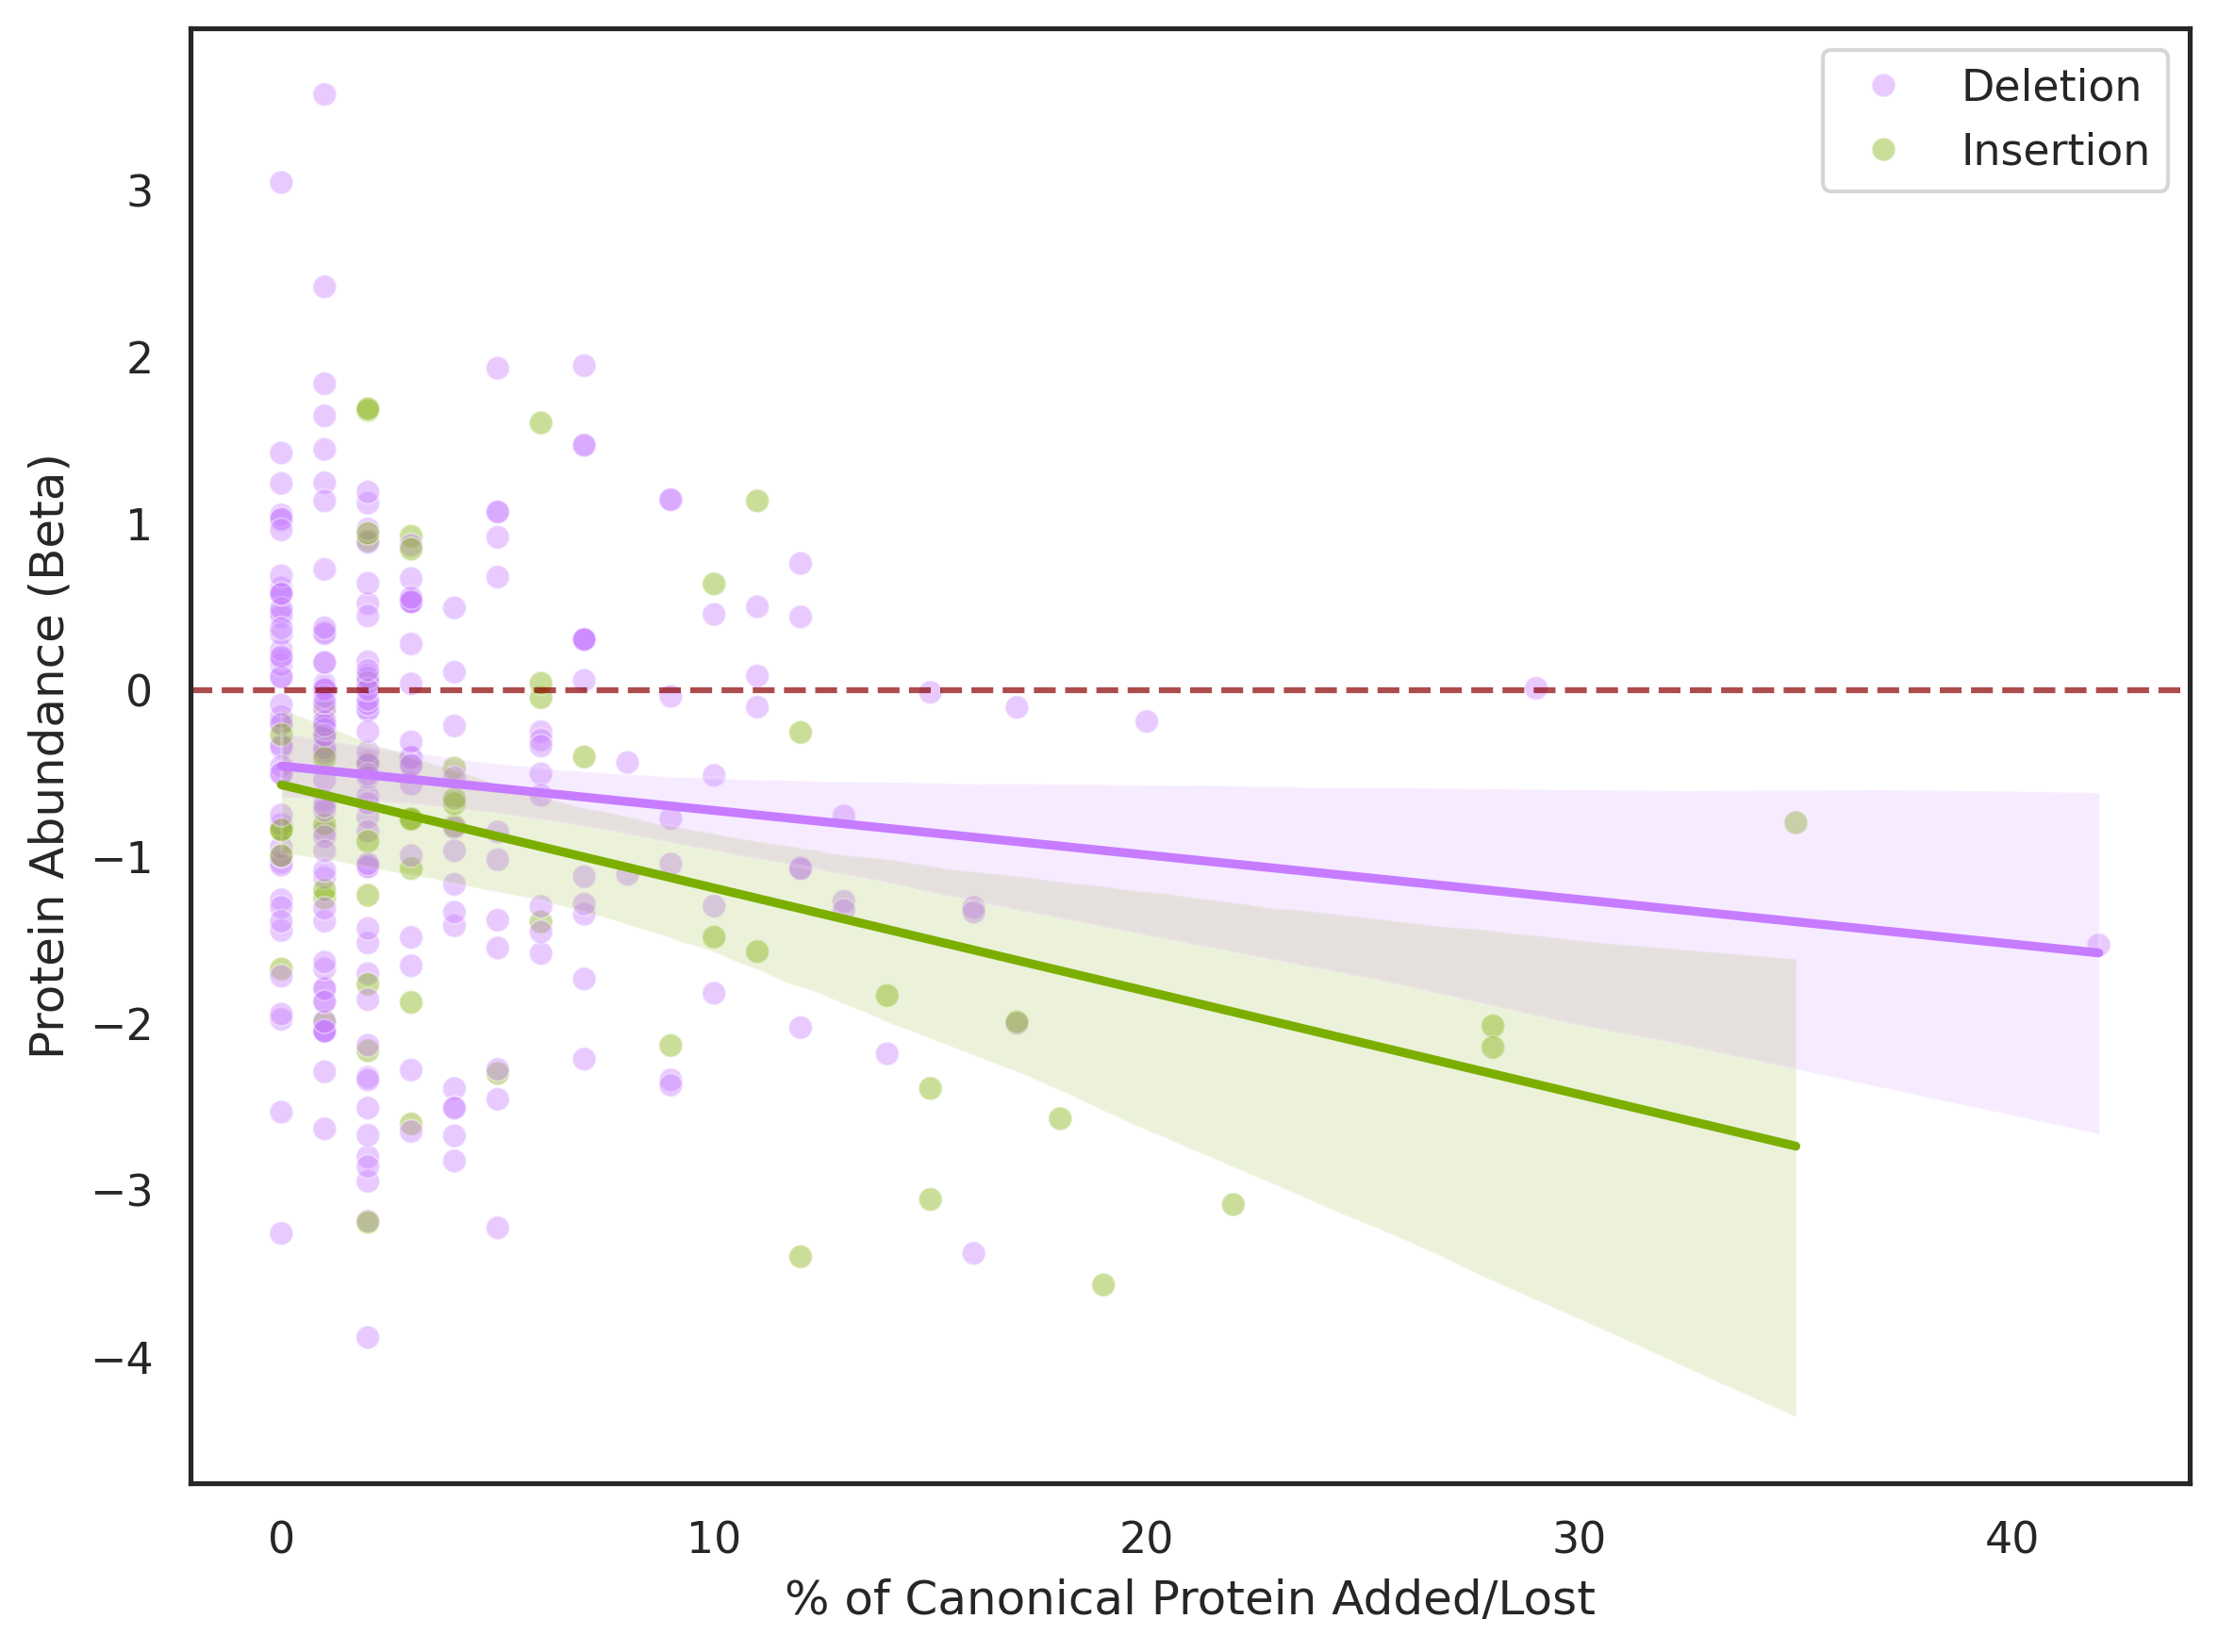

In [133]:
# Beta vs InFrame Proportion
inframe_data_imp = z_plot[
    (z_plot['Max_DSM_Score'] >= 0.2) &
    (z_plot['FacetGroup'] == 'InFrame') &
    (z_plot['aa_size'].notna()) &
    (~z_plot['Is_Minor'])
]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=inframe_data_imp, x='InFrame_Proportion', y='Beta', hue='InFrame_Type', palette={'Insertion': '#7cae00', 'Deletion': '#c77cff'}, alpha=0.4)
sns.regplot(data=inframe_data_imp[inframe_data_imp['InFrame_Type']=='Insertion'], x='InFrame_Proportion', y='Beta', scatter=False, color='#7cae00')
sns.regplot(data=inframe_data_imp[inframe_data_imp['InFrame_Type']=='Deletion'], x='InFrame_Proportion', y='Beta', scatter=False, color='#c77cff')
plt.axhline(0, color='darkred', linestyle='--', alpha=0.7)
plt.xlabel('% of Canonical Protein Added/Lost')
plt.ylabel('Protein Abundance (Beta)')
plt.legend(title='', loc='upper right')
plt.show()
#plt.savefig("SpliceAI_Beta_vs_InFrame_Proportion.png", dpi=300)
plt.close()

In [134]:
# Regression Statistics
for event_type, group in inframe_data_imp.groupby('InFrame_Type'):
    if len(group) > 1:
        model = smf.ols('Beta ~ InFrame_Proportion', data=group).fit()
        intercept = model.params['Intercept']
        slope = model.params['InFrame_Proportion']
        r_sq = model.rsquared
        p_val = model.pvalues['InFrame_Proportion']

        print(f"=== {event_type.upper()} ===")
        print(f"Equation: Beta = {intercept:.4f} + ({slope:.4f} * InFrame_Proportion)")
        print(f"Interpretation: For every 1% lost/added, Beta changes by {slope:.4f}")
        print(f"R-squared: {r_sq:.4f} | p-value: {p_val:.4e}\n")

=== DELETION ===
Equation: Beta = -0.4529 + (-0.0267 * InFrame_Proportion)
Interpretation: For every 1% lost/added, Beta changes by -0.0267
R-squared: 0.0116 | p-value: 8.9270e-02

=== INSERTION ===
Equation: Beta = -0.5660 + (-0.0620 * InFrame_Proportion)
Interpretation: For every 1% lost/added, Beta changes by -0.0620
R-squared: 0.1395 | p-value: 4.5834e-03



In [135]:
# Major vs Minor Comparison
z_minor_comp_all = z.copy()
z_minor_comp_all['Max_DSM_Score'] = z_minor_comp_all[dsm_cols].max(axis=1)
z_minor_comp_all['Is_Minor'] = z_minor_comp_all['EVENT_CLASS'].str.contains('_Minor', na=False)
z_minor_comp_all['Clean_Class'] = z_minor_comp_all['EVENT_CLASS'].str.replace('_Minor|_PTC', '', regex=True)
z_minor_comp_all['Is_NonCoding'] = (z_minor_comp_all['EVENT_CLASS'] == 'NonCoding') | z_minor_comp_all['EVENT_CLASS'].str.contains('_NonCoding', na=False)

facet_conditions = [
    z_minor_comp_all['Clean_Class'].str.contains('Frameshift', na=False),
    z_minor_comp_all['Clean_Class'].str.contains('InFrame', na=False)
]
z_minor_comp_all['FacetGroup'] = np.select(facet_conditions, ['Frameshift', 'InFrame'], default='Other')

z_minor_comp_all = z_minor_comp_all[
    (z_minor_comp_all['FacetGroup'] != 'Other') &
    (z_minor_comp_all['Max_DSM_Score'] >= 0.2) &
    (~z_minor_comp_all['Is_NonCoding'])
].copy()

z_minor_comp_all['Status'] = np.where(z_minor_comp_all['Is_Minor'], 'Canonical site', 'New site')

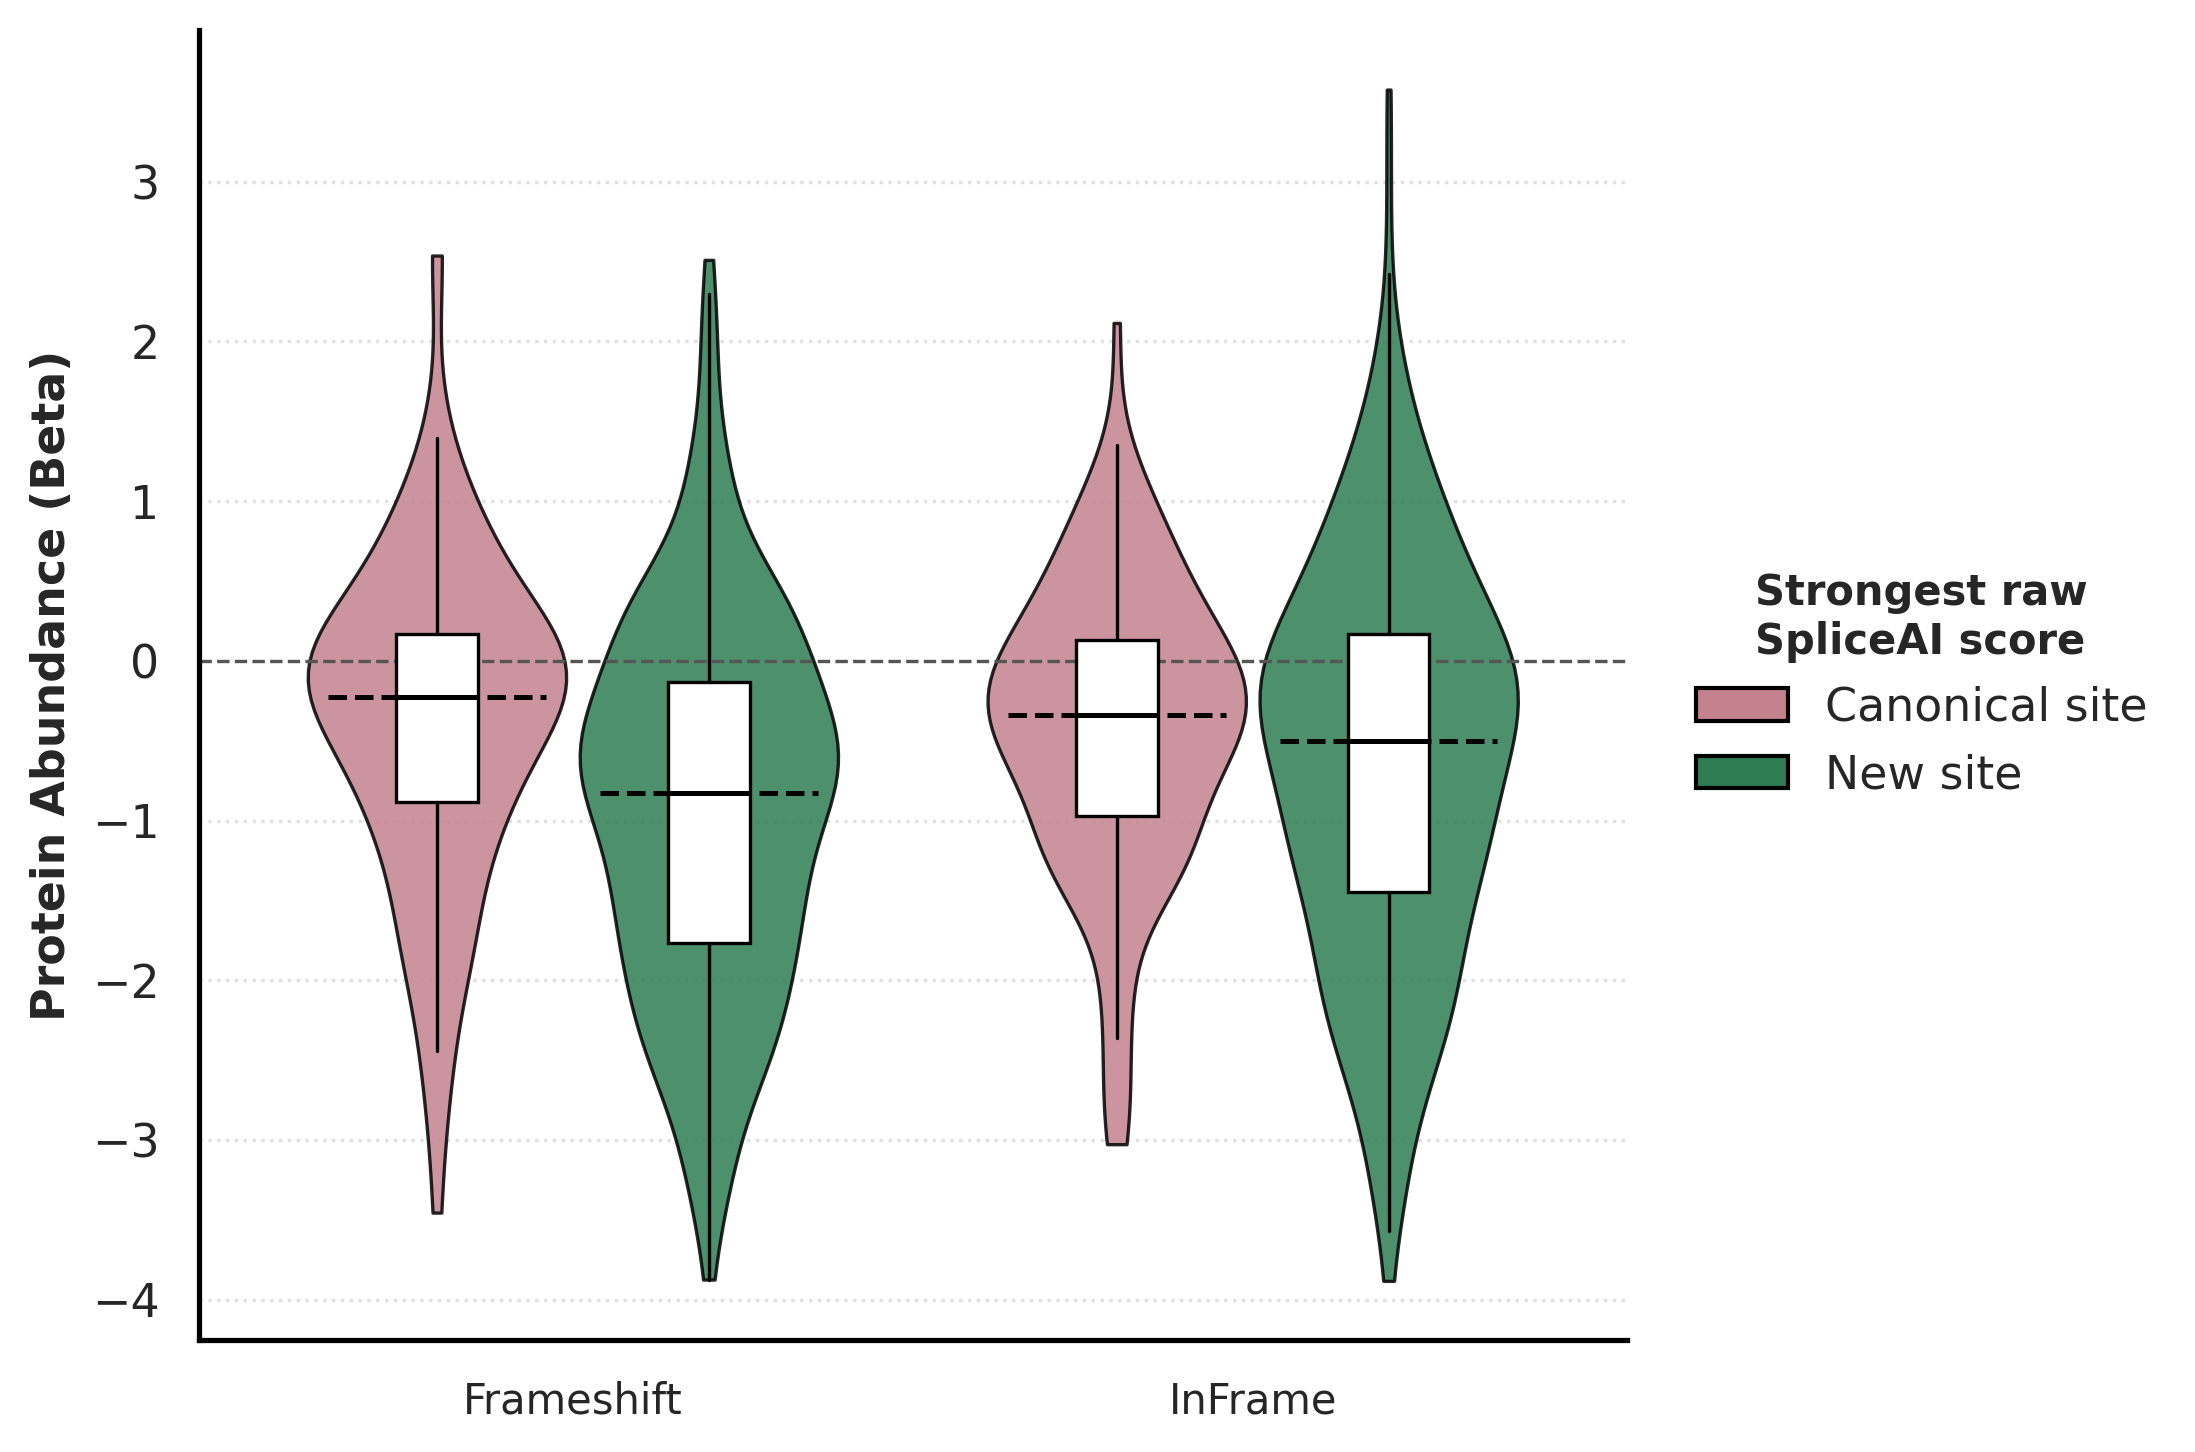

In [136]:
# Enforce ordering
status_order = ["Canonical site", "New site"]
facet_order = ["Frameshift", "InFrame"]

z_minor_comp_all['Status'] = pd.Categorical(
    z_minor_comp_all['Status'], categories=status_order, ordered=True
)
z_minor_comp_all['FacetGroup'] = pd.Categorical(
    z_minor_comp_all['FacetGroup'], categories=facet_order, ordered=True
)

# Colours
palette = ["#C4828E", "#2E7D52"]  # [Canonical site, New site]

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=300)

# Define x-coordinates for dodged elements
# Frameshift: Canonical = -0.2, New = 0.2
# InFrame: Canonical = 0.8, New = 1.2
positions = {
    ("Frameshift", "Canonical site"): 0 - 0.2,
    ("Frameshift", "New site"): 0 + 0.2,
    ("InFrame", "Canonical site"): 1 - 0.2,
    ("InFrame", "New site"): 1 + 0.2,
}

# Plot Violins & Boxplots
for (facet, status), pos in positions.items():
    subset = z_minor_comp_all[
        (z_minor_comp_all['FacetGroup'] == facet) & 
        (z_minor_comp_all['Status'] == status)
    ]['Beta'].dropna()

    if len(subset) == 0:
        continue

    color = palette[0] if status == "Canonical site" else palette[1]

    # Violin
    vp = ax.violinplot(
        subset,
        positions=[pos],
        widths=0.38,
        showmeans=False,
        showextrema=False,
        showmedians=False,
    )
    for pc in vp['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.8)
        pc.set_alpha(0.85)

    # Boxplot
    bp = ax.boxplot(
        subset,
        positions=[pos],
        widths=0.12,
        patch_artist=True,
        showfliers=False,
        manage_ticks=False,
        boxprops=dict(facecolor='white', edgecolor='black', linewidth=0.8, zorder=3),
        whiskerprops=dict(color='black', linewidth=0.8, zorder=3),
        capprops=dict(color='none'),
        medianprops=dict(color='black', linewidth=1.2, zorder=4)
    )

    # Add dashed median errorbar
    med = np.median(subset)
    ax.plot([pos - 0.16, pos + 0.16], [med, med], color='black', linestyle='--', linewidth=1.2, zorder=5)

# Y = 0 reference line
ax.axhline(0, color='#555555', linestyle='--', linewidth=0.8, zorder=1)

# Axes & Grid Setup
ax.set_xticks([0, 1])
ax.set_xticklabels(facet_order, fontsize=10)
ax.set_xlim(-0.55, 1.55)

ax.set_ylabel('Protein Abundance (Beta)', fontsize=11, fontweight='bold')
ax.set_xlabel('')

ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')

ax.yaxis.grid(True, linestyle=':', color='#E0E0E0', linewidth=0.8)
ax.xaxis.grid(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#C4828E", edgecolor="black", label="Canonical site"),
    Patch(facecolor="#2E7D52", edgecolor="black", label="New site")
]
ax.legend(
    handles=legend_elements,
    title="Strongest raw\nSpliceAI score",
    title_fontproperties={'weight': 'bold', 'size': 10},
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
#plt.savefig("SpliceAI_Beta_Major_vs_Minor_perfect.png", dpi=300, bbox_inches='tight')
plt.show()